In [50]:
#!/usr/bin/env python3
import sys
import os
import glob
import re
import cv2
import numpy as np
import matplotlib
matplotlib.use('TkAgg')  # Try this backend for displaying plots
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.widgets import Slider, Button
from tqdm import tqdm  # For progress bars (install with pip install tqdm if needed)
import transforms3d.euler as euler


In [51]:
print(f"OpenCV version: {cv2.__version__}")

OpenCV version: 4.6.0


In [52]:
# file_path = '/home/ranger/04_13_2025_01_55_41_trial_1/np_data_04_13_2025_01_55_41.npz'
# gen_fpath = '/home/ranger/04_13_2025_01_55_41_trial_1'

file_path = '/home/ranger/04_13_2025_02_26_49_trial_2/np_data_04_13_2025_02_26_49.npz'
gen_fpath = '/home/ranger/04_13_2025_02_26_49_trial_2'

# Load the NPZ file
npz_file = np.load(file_path, allow_pickle=True)
keys = list(npz_file.keys())
print(f"Keys found: {keys}")
for key in keys:
    print(f"{key} has shape: {npz_file[key].shape}")
# Create a directory to save plots
plot_dir = os.path.join(os.path.dirname(file_path), "plots")
os.makedirs(plot_dir, exist_ok=True)
print(f"Saving plots to: {plot_dir}")

Keys found: ['q', 'dq', 't', 'input', 'u', 'qd', 'dqd', 'depth', 'depth_d', 'quat', 'alt', 'yaw_d', 'stereo_depth', 'stereo_point']
q has shape: (73830, 10)
dq has shape: (73830, 10)
t has shape: (73830,)
input has shape: (73830, 10)
u has shape: (73830, 10)
qd has shape: (73830, 10)
dqd has shape: (73830, 10)
depth has shape: (73830,)
depth_d has shape: (73830,)
quat has shape: (73830, 4)
alt has shape: (147660,)
yaw_d has shape: (147660,)
stereo_depth has shape: (73830,)
stereo_point has shape: (2, 73830)
Saving plots to: /home/ranger/04_13_2025_02_26_49_trial_2/plots


In [53]:
def natural_sort_key(s):
    """
    Sort strings containing numbers naturally (e.g., frame1.npy, frame2.npy, ..., frame10.npy)
    """
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

def load_depth_files(directory_path):
    """Load and sort all depth .npy files from the given directory"""
    if not os.path.exists(directory_path):
        print(f"Error: Directory '{directory_path}' not found.")
        return []
        
    # Find all .npy files in the directory
    depth_files = glob.glob(os.path.join(directory_path, "*.npy"))
    
    if not depth_files:
        print(f"Error: No .npy files found in '{directory_path}'")
        return []
    
    # Sort files naturally (so frame10 comes after frame9, not after frame1)
    depth_files.sort(key=natural_sort_key)
    # print(f"Found {len(depth_files)} depth data files.")
    
    return depth_files


### Motor Positions and Desired Positions (q and dq)

In [54]:
print(npz_file['t'][:50])

[1.59442902 1.59838486 1.60308385 1.60629845 1.60933304 1.61330581
 1.61626959 1.61927485 1.62354994 1.62827849 1.63127637 1.63426828
 1.63827777 1.64379263 1.64961648 1.65537834 1.66166019 1.66835642
 1.6734252  1.67950058 1.6867063  1.6934886  1.69975805 1.70539379
 1.71240759 1.72154188 1.72775984 1.73477435 1.73937678 1.74465179
 1.74829888 1.75178671 1.75652623 1.76028776 1.76519394 1.7682755
 1.77127481 1.77430654 1.77747107 1.78327775 1.78696918 1.79035354
 1.79430389 1.79827452 1.80128098 1.80427742 1.80729628 1.81135106
 1.81529856 1.81827068]


In [55]:
print(npz_file['u'].shape)
u_data = npz_file['u']
# Define range to plot
start_idx = 0
end_idx = u_data.shape[0]

# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(u_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

for i in range(10):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot both q and dqd on same axis
    ax.plot(x, u_data[start_idx:end_idx, i], 'b-', label=f'u{i+1} (Desired Position)', linewidth=0.5)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('radians')
    ax.set_title(f'Dimension {i+1}')
    
    # Add legend
    ax.legend(loc='best')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits to ensure both datasets are visible
    y_min = min(np.min(u_data[start_idx:end_idx, i]), np.min(u_data[start_idx:end_idx, i]))
    y_max = max(np.max(u_data[start_idx:end_idx, i]), np.max(u_data[start_idx:end_idx, i]))
    
    # Add some padding to the y-axis limits
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(plot_dir, f"u_motor_{i+1}.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot for dimension {i+1} to {save_path}")
    
    # Close the plot to free memory
    plt.close(fig)


(73830, 10)
Saved plot for dimension 1 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_1.png
Saved plot for dimension 2 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_2.png
Saved plot for dimension 3 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_3.png
Saved plot for dimension 4 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_4.png
Saved plot for dimension 5 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_5.png
Saved plot for dimension 6 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_6.png
Saved plot for dimension 7 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_7.png
Saved plot for dimension 8 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_8.png
Saved plot for dimension 9 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_9.png
Saved plot for dimension 10 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/u_motor_10.png


In [56]:
# Get the data
q_data = npz_file['q']
qd_data = npz_file['qd']

print(f"q data shape: {q_data.shape}")
print(f"qd data shape: {qd_data.shape}")
    
# Define range to plot
start_idx = 0
end_idx = q_data.shape[0]

# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(q_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

# Create individual plots for each dimension
for i in range(10):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot both q and dqd on same axis
    # ax.plot(x, q_data[start_idx:end_idx, i], 'b-', label=f'q{i+1} (Position)', linewidth=1.5)
    ax.plot(x, qd_data[start_idx:end_idx, i], 'r-', label=f'qd{i+1} (Desired Position)', linewidth=0.8)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('radians')
    ax.set_title(f'Dimension {i+1}: Position and Desired Position')
    
    # Add legend
    ax.legend(loc='best')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits to ensure both datasets are visible
    y_min = min(np.min(q_data[start_idx:end_idx, i]), np.min(qd_data[start_idx:end_idx, i]))
    y_max = max(np.max(q_data[start_idx:end_idx, i]), np.max(qd_data[start_idx:end_idx, i]))
    
    # Add some padding to the y-axis limits
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(plot_dir, f"position_motor_{i+1}.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot for dimension {i+1} to {save_path}")
    
    # Close the plot to free memory
    plt.close(fig)

# Create a combined figure with all dimensions (5x2 grid)
fig, axes = plt.subplots(5, 2, figsize=(18, 24))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    
    # Plot both q and dqd on same axis
    # ax.plot(x, q_data[start_idx:end_idx, i], 'b-', label=f'q{i+1}', linewidth=1.2)
    ax.plot(x, qd_data[start_idx:end_idx, i], 'r-', label=f'qd{i+1}', linewidth=0.8)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('radians')
    ax.set_title(f'Motor {i+1}')
    
    # Add legend
    ax.legend(loc='best', fontsize='small')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits
    y_min = min(np.min(q_data[start_idx:end_idx, i]), np.min(qd_data[start_idx:end_idx, i]))
    y_max = max(np.max(q_data[start_idx:end_idx, i]), np.max(qd_data[start_idx:end_idx, i]))
    
    # Add padding
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
# Save the combined plot
combined_path = os.path.join(plot_dir, "all_positions.png")
plt.savefig(combined_path, dpi=300)
print(f"Saved plot to {combined_path}")
plt.close()


q data shape: (73830, 10)
qd data shape: (73830, 10)
Saved plot for dimension 1 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_1.png
Saved plot for dimension 2 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_2.png
Saved plot for dimension 3 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_3.png
Saved plot for dimension 4 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_4.png
Saved plot for dimension 5 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_5.png
Saved plot for dimension 6 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_6.png
Saved plot for dimension 7 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_7.png
Saved plot for dimension 8 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_8.png
Saved plot for dimension 9 to /home/ranger/04_13_2025_02_26_49_trial_2/plots/position_motor_9.png
Saved plot for dimension 10 to /home/ranger/04_13_2025_02_26_49_t

### Velocities and Desired Velocities (dq and dqd)

In [6]:
# Get the data
dq_data = npz_file['dq']
dqd_data = npz_file['dqd']

print(f"dq data shape: {dq_data.shape}")
print(f"dqd data shape: {dqd_data.shape}")
    
# Define range to plot
start_idx = 0
end_idx = dq_data.shape[0]

# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(q_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

# Create individual plots for each dimension
for i in range(10):
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot both q and dqd on same axis
    ax.plot(x, dq_data[start_idx:end_idx, i], 'b-', label=f'dq{i+1} (Velocity)', linewidth=1.5)
    ax.plot(x, dqd_data[start_idx:end_idx, i], 'r-', label=f'dqd{i+1} (Desired Velocity)', linewidth=1.5)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(r'rad $\cdot$ sec$^{-1}$')
    ax.set_title(f'Motor {i+1}: Velocity and Desired Velocity')
    
    # Add legend
    ax.legend(loc='best')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits to ensure both datasets are visible
    y_min = min(np.min(dq_data[start_idx:end_idx, i]), np.min(dqd_data[start_idx:end_idx, i]))
    y_max = max(np.max(dq_data[start_idx:end_idx, i]), np.max(dqd_data[start_idx:end_idx, i]))
    
    # Add some padding to the y-axis limits
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    
    # Save the plot
    save_path = os.path.join(plot_dir, f"velocity_motor_{i+1}.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved plot for dimension {i+1} to {save_path}")
    
    # Close the plot to free memory
    plt.close(fig)

# Create a combined figure with all dimensions (5x2 grid)
fig, axes = plt.subplots(5, 2, figsize=(18, 24))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    
    # Plot both q and dqd on same axis
    ax.plot(x, q_data[start_idx:end_idx, i], 'b-', label=f'dq{i+1}', linewidth=1.2)
    ax.plot(x, qd_data[start_idx:end_idx, i], 'r-', label=f'dqd{i+1}', linewidth=1.2)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(r'rad $\cdot$ sec$^{-1}$')
    ax.set_title(f'Motor {i+1}')
    
    # Add legend
    ax.legend(loc='best', fontsize='small')
    
    # Add grid for readability
    ax.grid(True, alpha=0.3)
    
    # Calculate y-axis limits
    y_min = min(np.min(dq_data[start_idx:end_idx, i]), np.min(dqd_data[start_idx:end_idx, i]))
    y_max = max(np.max(dq_data[start_idx:end_idx, i]), np.max(dqd_data[start_idx:end_idx, i]))
    
    # Add padding
    y_range = y_max - y_min
    y_min -= 0.1 * y_range
    y_max += 0.1 * y_range
    
    ax.set_ylim(y_min, y_max)

plt.tight_layout()

# Save the combined plot
combined_path = os.path.join(plot_dir, "all_velocities.png")
plt.savefig(combined_path, dpi=300)
print(f"Saved plot to {combined_path}")
plt.close()


dq data shape: (40297, 10)
dqd data shape: (40297, 10)
Saved plot for dimension 1 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_1.png
Saved plot for dimension 2 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_2.png
Saved plot for dimension 3 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_3.png
Saved plot for dimension 4 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_4.png
Saved plot for dimension 5 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_5.png
Saved plot for dimension 6 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_6.png
Saved plot for dimension 7 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_7.png
Saved plot for dimension 8 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_8.png
Saved plot for dimension 9 to /home/ranger/04_13_2025_01_55_41_trial_1/plots/velocity_motor_9.png
Saved plot for dimension 10 to /home/ranger/04_13_2025_01_55_41

### Depth and Desired Depth

In [6]:
depth_data = npz_file['depth']
depth_d_data = npz_file['depth_d']

print(f"depth data shape: {depth_data.shape}")
# Define range to plot
start_idx = 0
end_idx = depth_data.shape[0]

# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(depth_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

fig, ax = plt.subplots(figsize=(12, 7))

# Plot both q and dqd on same axis
ax.plot(x, depth_data[start_idx:end_idx], 'b-', label='Depth', linewidth=1.5)
ax.plot(x, depth_d_data[start_idx:end_idx], 'r-', label='Desired Depth', linewidth=1.5)

# Add labels and title
ax.set_xlabel(x_label)
ax.set_ylabel('Depth (meters)')
ax.set_title('Depth and Desired Depth')

# Add legend
ax.legend(loc='best')

# Add grid for readability
ax.grid(True, alpha=0.3)

# Calculate y-axis limits to ensure both datasets are visible
y_min = min(np.min(depth_data[start_idx:end_idx]), np.min(depth_d_data[start_idx:end_idx]))
y_max = max(np.max(depth_data[start_idx:end_idx]), np.max(depth_d_data[start_idx:end_idx]))

# Add some padding to the y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

ax.set_ylim(y_min, y_max)

plt.tight_layout()

# Save the plot
save_path = os.path.join(plot_dir, f"depth_data.png")
plt.savefig(save_path, dpi=300)
print(f"Saved plot for depth to {save_path}")

# Close the plot to free memory
plt.close(fig)


# Calculate errors
depth_error = depth_data[start_idx:end_idx] - depth_d_data[start_idx:end_idx]
rmse = np.sqrt(np.mean(np.square(depth_error)))
mae = np.mean(np.abs(depth_error))
max_error = np.max(np.abs(depth_error))

# Add error metrics to plot
error_text = f"RMSE: {rmse:.4f} m\nMAE: {mae:.4f} m\nMax Error: {max_error:.4f} m"
print(error_text)

depth data shape: (73830,)
Saved plot for depth to /home/ranger/04_13_2025_02_26_49_trial_2/plots/depth_data.png
RMSE: 0.2132 m
MAE: 0.1414 m
Max Error: 0.8900 m


### Stereo Depth Images

In [7]:
stereo_depth_data = npz_file['stereo_depth']
print(stereo_depth_data[0:50])
start_idx = 0
end_idx = stereo_depth_data.shape[0]
print(stereo_depth_data.shape)
# Create a figure and get the axes object
fig, ax = plt.subplots(figsize=(12, 6))
# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(stereo_depth_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

if len(t_data) == len(stereo_depth_data):
    x = t_data[start_idx:end_idx]
    x_label = 'Time'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

# Plot using the axes object
ax.plot(x, stereo_depth_data[start_idx:end_idx])

# Add labels and title to the axes object
ax.set_xlabel(x_label)
ax.set_ylabel('Depth (meters)')
ax.set_title('Stereo Depth')
ax.grid(True)

plt.tight_layout()

# Save the plot
save_path = os.path.join(plot_dir, f"stereo_depth_plot.png")
plt.savefig(save_path, dpi=300)
print(f"Saved plot for stereo depth to {save_path}")
plt.close(fig)  # Close using the figure object

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
(73830,)
Saved plot for stereo depth to /home/ranger/04_13_2025_02_26_49_trial_2/plots/stereo_depth_plot.png


### Yaw Tracking 

In [44]:
quat = npz_file['quat']
yaw_d = npz_file['yaw_d']

yaw_d_resampled = yaw_d[::2]  # Take every other value
yaw_d = yaw_d_resampled
q_eul = np.zeros((len(quat), 3))  # Create array to store roll, pitch, yaw
for i in range(len(quat)):
    q_eul[i] = euler.quat2euler(quat[i], 'szyx')  # Convert each quaternion

# Extract yaw angles (third component)
yaw = q_eul[:, 2]
# Create a nice-looking plot
plt.figure(figsize=(14, 8))

# Check if time data is available
if 't' in npz_file and len(npz_file['t']) >= len(quat):
    # Use time as x-axis if available
    t = npz_file['t'][:len(quat)]
    plt.plot(t, yaw, 'b-', linewidth=2, label='Actual Yaw')
    plt.plot(t, yaw_d, 'r-', linewidth=2, label='Desired Yaw')
    plt.xlabel('Time')
else:
    # Otherwise use indices
    indices = np.arange(len(yaw))
    plt.plot(indices, yaw, 'b-', linewidth=2, label='Actual Yaw')
    plt.plot(indices, yaw_d, 'r-', linewidth=2, label='Desired Yaw')
    plt.xlabel('Sample Index')

# Convert radians to degrees if needed
# Uncomment these if your angles are in radians and you want to display in degrees
# yaw = np.degrees(yaw)
# yaw_d = np.degrees(yaw_d)

# Set labels and title
plt.ylabel('Yaw Angle')
plt.title('Comparison of Actual vs Desired Yaw Angle')

# Add grid and legend
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

# Calculate y-axis limits to ensure both datasets are visible
y_min = min(np.min(yaw), np.min(yaw_d))
y_max = max(np.max(yaw), np.max(yaw_d))

# Add some padding to the y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

plt.ylim(y_min, y_max)

# Tight layout for better appearance
plt.tight_layout()
# Save the plot
save_path = os.path.join(plot_dir, f"yaw_vs_yaw_desired.png")
# Save the plot if a path is provided
if save_path:
    plt.savefig(save_path, dpi=300)
    print(f"Plot saved to: {save_path}")

# Create an additional plot showing the error between actual and desired yaw
plt.figure(figsize=(14, 6))

# Calculate yaw error
yaw_error = yaw - yaw_d

# Plot the error
if 't' in npz_file and len(npz_file['t']) >= len(quat):
    t = npz_file['t'][:len(yaw_error)]
    plt.plot(t, yaw_error, 'g-', linewidth=2)
    plt.xlabel('Time')
else:
    plt.plot(indices, yaw_error, 'g-', linewidth=2)
    plt.xlabel('Sample Index')

plt.ylabel('Yaw Error (Actual - Desired)')
plt.title('Yaw Tracking Error')
plt.grid(True, alpha=0.3)

# Add a horizontal line at zero for reference
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save the error plot if a path is provided
if save_path:
    error_path = save_path.replace('.png', '_error.png')
    plt.savefig(error_path, dpi=300)
    print(f"Error plot saved to: {error_path}")

# Calculate and print some statistics about the tracking performance
mean_error = np.mean(yaw_error)
rmse = np.sqrt(np.mean(yaw_error**2))
max_error = np.max(np.abs(yaw_error))

print("\nYaw Tracking Performance:")
print(f"Mean Error: {mean_error:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Maximum Absolute Error: {max_error:.4f}")

# Show the plots
plt.show()



Plot saved to: /home/ranger/04_13_2025_01_55_41_trial_1/plots/yaw_vs_yaw_desired.png
Error plot saved to: /home/ranger/04_13_2025_01_55_41_trial_1/plots/yaw_vs_yaw_desired_error.png

Yaw Tracking Performance:
Mean Error: 0.2620
RMSE: 0.9820
Maximum Absolute Error: 3.2516


### Depth Images Recording

In [57]:
stereo_depth_fname = 'video/05_16_2025_11_03_56_trial_2/depth_data'

In [58]:


def visualize_depth_sequence(directory_path, start_idx=0, end_idx=None):
    """
    Interactive visualization with fixed figure for Jupyter notebooks
    """
    from ipywidgets import interact, interactive, IntSlider, Output
    import matplotlib.pyplot as plt
    from IPython.display import display
    
    # Try using widget backend for better interactivity
    try:
        %matplotlib widget
    except:
        %matplotlib inline
        print("Note: For better interactivity, run '%matplotlib widget' in a cell before calling this function")
    
    depth_files = load_depth_files(directory_path)
    if not depth_files:
        return
    
    if end_idx is None or end_idx > len(depth_files):
        end_idx = len(depth_files)
    
    depth_files = depth_files[start_idx:end_idx]
    
    # Create output widget for display
    out = Output()
    
    # Create the figure and initial plot
    with out:
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Load the first frame
        first_depth = np.load(depth_files[0])
        vmin = np.min(first_depth)
        vmax = np.max(first_depth)
        
        # Initial plot
        im = ax.imshow(first_depth, cmap='viridis', vmin=vmin, vmax=vmax)
        title = ax.set_title(f'Depth Data - Frame: {start_idx}')
        cbar = fig.colorbar(im, ax=ax, label='Disparity')
        # plt.tight_layout()
    
    # Update function with explicit display update
    def update_frame(frame_idx):
        with out:
            try:
                depth_data = np.load(depth_files[frame_idx])
                
                if np.isnan(depth_data).any() or np.isinf(depth_data).any():
                    depth_data = np.nan_to_num(depth_data, nan=0.0, posinf=vmax, neginf=vmin)
                
                im.set_data(depth_data)
                title.set_text(f'Depth Data - Frame: {frame_idx + start_idx}')

                # Force redraw
                fig.canvas.draw()
                plt.draw()
            except Exception as e:
                print(f"Error loading frame {frame_idx}: {e}")
    
    # Create the interactive widget using interactive instead of interact
    slider = IntSlider(
        min=0,
        max=len(depth_files)-1,
        step=1,
        value=0,
        description='Frame:',
        continuous_update=True  # Try True to update while dragging
    )
    
    # Connect the widget to the update function
    interactive_plot = interactive(update_frame, frame_idx=slider)
    
    # Display both the output and the widget
    display(slider, out)
    
    # Initial update
    update_frame(0)
    
    return fig, ax

def create_depth_animation(directory_path, output_path=None, start_idx=0, end_idx=None, 
                          interval=100, dpi=100, fps=10):
    """
    Create an animation from a sequence of depth data .npy files
    
    Args:
        directory_path (str): Path to directory containing depth .npy files
        output_path (str): Path to save the animation (default: auto-generate)
        start_idx (int): Index of first frame to include
        end_idx (int): Index of last frame to include (None for all)
        interval (int): Delay between frames in milliseconds
        dpi (int): DPI for saved animation
        fps (int): Frames per second for saved animation
    """
    depth_files = load_depth_files(directory_path)
    if not depth_files:
        return
    
    if end_idx is None or end_idx > len(depth_files):
        end_idx = len(depth_files)
    
    depth_files = depth_files[start_idx:end_idx]
    
    # Generate output path if not provided
    if output_path is None:
        output_path = os.path.join(os.path.dirname(directory_path), 
                                   f"depth_animation_{start_idx}_{end_idx-1}.mp4")
    
    # Load the first file to get dimensions and create the plot
    try:
        first_depth = np.load(depth_files[0])
        
        # Set initial min/max values for the colormap
        vmin = np.min(first_depth)
        vmax = np.max(first_depth)
        
        # Handle NaN or inf values
        if np.isnan(first_depth).any() or np.isinf(first_depth).any():
            first_depth = np.nan_to_num(first_depth, nan=0.0, posinf=vmax, neginf=vmin)
    
    except Exception as e:
        print(f"Error loading first depth file: {e}")
        return
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(first_depth, cmap='viridis', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax, label='Disparity')
    title = ax.set_title(f'Frame: {start_idx}')
    
    # Function to update the animation
    def update_frame(frame_idx):
        try:
            depth_data = np.load(depth_files[frame_idx])
            
            # Handle NaN or inf values
            if np.isnan(depth_data).any() or np.isinf(depth_data).any():
                depth_data = np.nan_to_num(depth_data, nan=0.0, posinf=vmax, neginf=vmin)
            
            im.set_data(depth_data)
            title.set_text(f'Frame: {frame_idx + start_idx}')
            return [im, title]
        except Exception as e:
            print(f"Error in animation frame {frame_idx}: {e}")
            return [im, title]
    
    print(f"Creating animation with {len(depth_files)} frames...")
    ani = animation.FuncAnimation(fig, update_frame, frames=len(depth_files),
                                 interval=interval, blit=True)
    
    # Save the animation
    if output_path.endswith('.mp4'):
        writer = animation.FFMpegWriter(fps=fps)
        ani.save(output_path, writer=writer, dpi=dpi)
    else:
        ani.save(output_path, dpi=dpi, writer='pillow')
    
    print(f"Animation saved to {output_path}")
    plt.close()

def create_depth_montage(directory_path, output_path=None, num_frames=9, 
                         start_idx=0, end_idx=None, figsize=(15, 12)):
    """
    Create a montage of selected frames from depth data sequence
    
    Args:
        directory_path (str): Path to directory containing depth .npy files
        output_path (str): Path to save the montage (default: auto-generate)
        num_frames (int): Number of frames to include in montage
        start_idx (int): Index of first frame to include
        end_idx (int): Index of last frame to include (None for all)
        figsize (tuple): Figure size in inches
    """
    depth_files = load_depth_files(directory_path)
    if not depth_files:
        return
    
    if end_idx is None or end_idx > len(depth_files):
        end_idx = len(depth_files)
    
    depth_files = depth_files[start_idx:end_idx]
    
    # Generate output path if not provided
    if output_path is None:
        output_path = os.path.join(os.path.dirname(directory_path), 
                                   f"depth_montage_{start_idx}_{end_idx-1}.png")
    
    # Select frames evenly spaced throughout the sequence
    if num_frames > len(depth_files):
        num_frames = len(depth_files)
        selected_indices = list(range(len(depth_files)))
    else:
        selected_indices = [int(i * (len(depth_files) - 1) / (num_frames - 1)) for i in range(num_frames)]
    
    selected_files = [depth_files[i] for i in selected_indices]
    
    # Calculate grid dimensions
    grid_size = int(np.ceil(np.sqrt(num_frames)))
    
    # Create montage
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten()
    
    # Load and plot each selected frame
    vmin = None
    vmax = None
    
    for i, (ax, file_path) in enumerate(zip(axes, selected_files)):
        if i >= num_frames:
            ax.axis('off')
            continue
            
        try:
            depth_data = np.load(file_path)
            
            # Set consistent colormap limits
            if vmin is None:
                vmin = np.min(depth_data)
            if vmax is None:
                vmax = np.max(depth_data)
            
            # Handle NaN or inf values
            if np.isnan(depth_data).any() or np.isinf(depth_data).any():
                depth_data = np.nan_to_num(depth_data, nan=0.0, posinf=vmax, neginf=vmin)
            
            im = ax.imshow(depth_data, cmap='viridis', vmin=vmin, vmax=vmax)
            ax.set_title(f'Frame {selected_indices[i] + start_idx}')
            ax.axis('off')
        except Exception as e:
            print(f"Error loading frame {selected_indices[i]}: {e}")
            ax.axis('off')
    
    # Hide any unused subplots
    for i in range(num_frames, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    cbar = fig.colorbar(im, ax=axes, shrink=0.6, label='Disparity')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Montage saved to {output_path}")
    plt.show()
def convert_depth_npy_to_images(source_folder, output_folder=None, colormap=cv2.COLORMAP_VIRIDIS, 
                               quality=95, normalize=True, file_prefix="frame"):
    """
    Convert depth .npy files to jpg images with colormap visualization
    
    Args:
        source_folder (str): Path to folder containing depth .npy files
        output_folder (str): Path to folder where jpg images will be saved
        colormap (int): OpenCV colormap to use (default: COLORMAP_VIRIDIS)
        quality (int): JPEG quality (0-100)
        normalize (bool): Whether to normalize depth values across all frames
        file_prefix (str): Prefix for output filenames
    
    Returns:
        int: Number of files converted
    """
    # Check if source folder exists
    if not os.path.exists(source_folder):
        print(f"Error: Source directory '{source_folder}' not found.")
        return 0
    
    # Determine output folder if not specified
    if output_folder is None:
        # Get the parent directory of the source folder
        parent_dir = os.path.dirname(os.path.abspath(source_folder))
        output_folder = os.path.join(parent_dir, "depth")    
        
    # Find all .npy files in the source directory
    depth_files = glob.glob(os.path.join(source_folder, "*.npy"))
    
    if not depth_files:
        print(f"Error: No .npy files found in '{source_folder}'")
        return 0
    
    # Sort files naturally
    depth_files.sort(key=natural_sort_key)
    print(f"Found {len(depth_files)} depth data files.")
    
    # If we normalize globally, we need to find min/max values across all files
    global_min = float('inf')
    global_max = float('-inf')
    
    if normalize:
        print("Finding global min/max depth values...")
        for depth_file in tqdm(depth_files):
            try:
                depth_data = np.load(depth_file)
                
                # Skip NaN and inf values for min/max calculation
                valid_data = depth_data[~np.isnan(depth_data) & ~np.isinf(depth_data)]
                if len(valid_data) > 0:
                    file_min = np.min(valid_data)
                    file_max = np.max(valid_data)
                    
                    global_min = min(global_min, file_min)
                    global_max = max(global_max, file_max)
            except Exception as e:
                print(f"Error loading file {depth_file}: {e}")
        
        print(f"Global depth range: [{global_min:.4f}, {global_max:.4f}]")
        
        # If we couldn't find valid min/max (all files have errors or only contain NaN/inf)
        if global_min == float('inf') or global_max == float('-inf'):
            print("Warning: Could not determine valid global min/max. Using default 0-1 range.")
            global_min = 0
            global_max = 1
    
    # Process each depth file
    print("Converting depth files to images...")
    for i, depth_file in enumerate(tqdm(depth_files)):
        try:
            # Load depth data
            depth_data = np.load(depth_file)
            
            # Determine file-specific min/max if not normalizing globally
            if not normalize:
                valid_data = depth_data[~np.isnan(depth_data) & ~np.isinf(depth_data)]
                if len(valid_data) > 0:
                    depth_min = np.min(valid_data)
                    depth_max = np.max(valid_data)
                else:
                    depth_min = 0
                    depth_max = 1
            else:
                depth_min = global_min
                depth_max = global_max
            
            # Handle NaN or inf values
            depth_data = np.nan_to_num(depth_data, nan=depth_min, posinf=depth_max, neginf=depth_min)
            
            # Normalize to 0-255 range for 8-bit image
            depth_range = depth_max - depth_min
            if depth_range == 0:  # Avoid division by zero
                depth_range = 1
            
            normalized_depth = ((depth_data - depth_min) / depth_range * 255).astype(np.uint8)
            
            # Apply colormap
            colored_depth = cv2.applyColorMap(normalized_depth, colormap)
            
            # Extract base number from filename or use index
            try:
                # Try to extract the frame number from the filename (e.g., frame123.npy -> 123)
                file_basename = os.path.basename(depth_file)
                frame_num = int(re.search(r'(\d+)', file_basename).group(1))
            except (AttributeError, ValueError):
                # If extraction fails, use the index
                frame_num = i + 1
            
            # Save as JPG
            output_filename = f"{file_prefix}{frame_num}.jpg"
            output_path = os.path.join(output_folder, output_filename)
            cv2.imwrite(output_path, colored_depth, [cv2.IMWRITE_JPEG_QUALITY, quality])
            
        except Exception as e:
            print(f"Error processing {depth_file}: {e}")
    
    print(f"Converted {len(depth_files)} depth files to images in '{output_folder}'")
    return len(depth_files)

In [59]:
convert_depth_npy_to_images(stereo_depth_fname)

Found 3907 depth data files.
Finding global min/max depth values...


  0%|          | 0/3907 [00:00<?, ?it/s]

100%|██████████| 3907/3907 [00:07<00:00, 520.72it/s]


Global depth range: [0.0000, 0.9922]
Converting depth files to images...


100%|██████████| 3907/3907 [00:22<00:00, 170.78it/s]

Converted 3907 depth files to images in '/home/ranger/drl-turtle/ros2_ws/src/turtle_hardware/turtle_hardware/video/05_16_2025_11_03_56_trial_2/depth'


3907

In [9]:
create_depth_animation(stereo_depth_fname)

Found 2324 depth data files.
Creating animation with 2324 frames...


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1000x800', '-pix_fmt', 'rgba', '-r', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-y', 'video/05_16_2025_10_33_14_trial_1/depth_animation_0_2323.mp4']' returned non-zero exit status 255.

In [ ]:
create_depth_montage(stereo_depth_fname)

Found 2324 depth data files.


IntSlider(value=0, description='Frame:', max=2323)

Output()

(<Figure size 1000x800 with 2 Axes>,
 <AxesSubplot:title={'center':'Depth Data - Frame: 0'}>)

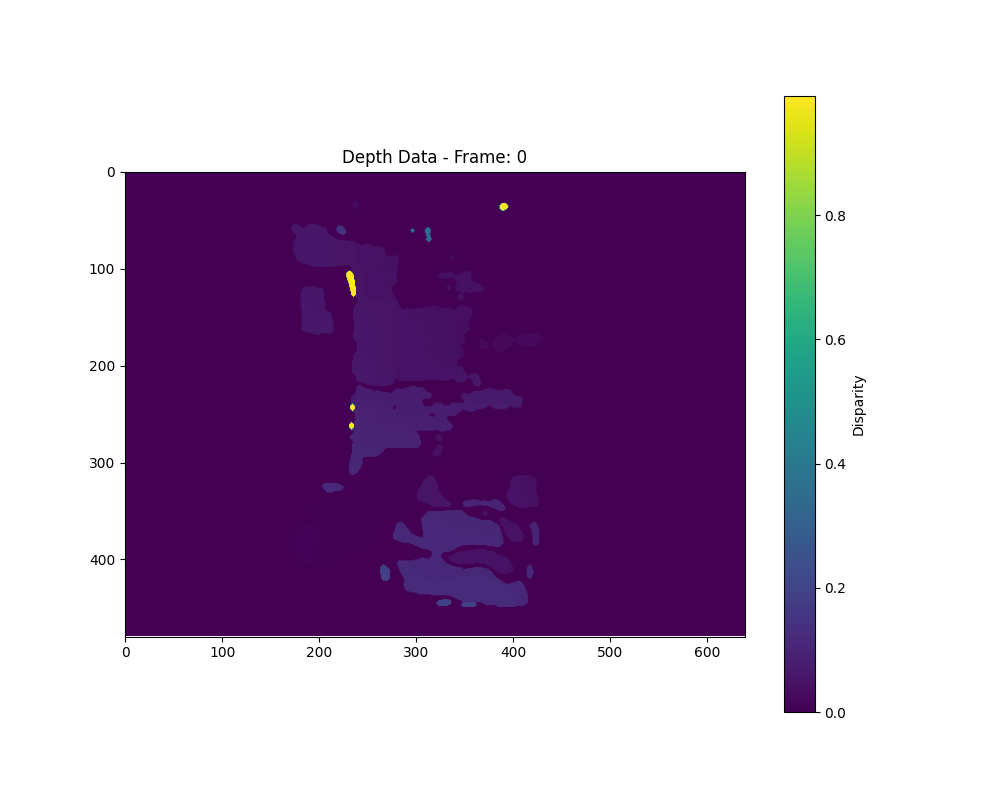

In [10]:
visualize_depth_sequence(stereo_depth_fname)

### Regular Stereo Footage

In [13]:
def create_video_from_images(image_folder, output_path, fps=30, extension="jpg"):
    """
    Create a video from a folder of images
    
    Args:
        image_folder (str): Path to folder containing images
        output_path (str): Path where to save the output video
        fps (int): Frames per second for the output video
        extension (str): File extension of the images to use
    
    Returns:
        bool: True if successful, False otherwise
    """
    # Check if folder exists
    if not os.path.exists(image_folder):
        print(f"Error: Directory '{image_folder}' not found.")
        return False
    
    # Find all image files in the directory
    image_files = glob.glob(os.path.join(image_folder, f"*.{extension}"))
    
    if not image_files:
        print(f"Error: No {extension} files found in '{image_folder}'")
        return False
    
    # Sort files naturally
    image_files.sort(key=natural_sort_key)
    print(f"Found {len(image_files)} images in '{image_folder}'")
    
    # Read first image to get dimensions
    first_image = cv2.imread(image_files[0])
    if first_image is None:
        print(f"Error: Could not read image '{image_files[0]}'")
        return False
    
    height, width, channels = first_image.shape
    
    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Use 'XVID' for .avi format
    video_writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Process each image
    print(f"Creating video: {output_path}")
    for image_file in tqdm(image_files):
        image = cv2.imread(image_file)
        if image is not None:
            video_writer.write(image)
    
    # Release the video writer
    video_writer.release()
    print(f"Video saved to {output_path}")
    
    return True

def create_stereo_videos(left_folder, right_folder, output_dir=None, fps=30, extension="jpg"):
    """
    Create separate videos from left and right image folders
    
    Args:
        left_folder (str): Path to folder containing left camera images
        right_folder (str): Path to folder containing right camera images
        output_dir (str): Directory to save output videos (default: current directory)
        fps (int): Frames per second for the output videos
        extension (str): File extension of the images to use
    """
    # Use current directory if output_dir is not specified
    if output_dir is None:
        output_dir = os.getcwd()
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Define output paths
    left_video_path = os.path.join(output_dir, "left_camera.mp4")
    right_video_path = os.path.join(output_dir, "right_camera.mp4")
    
    # Create videos
    left_success = create_video_from_images(left_folder, left_video_path, fps, extension)
    right_success = create_video_from_images(right_folder, right_video_path, fps, extension)
    
    # Check results
    if left_success and right_success:
        print("\nBoth videos created successfully:")
        print(f"Left camera video: {left_video_path}")
        print(f"Right camera video: {right_video_path}")
    else:
        print("\nThere were issues creating one or both videos.")

In [14]:
stereo_fname = 'video/05_16_2025_11_03_56_trial_2/'
# Create videos from image folders
create_stereo_videos(
    left_folder=stereo_fname + "left", 
    right_folder=stereo_fname + "right",
    output_dir=stereo_fname,
    fps=10,                             # Optional
    extension="jpg"                     # Optional
)

Found 3907 images in 'video/05_16_2025_11_03_56_trial_2/left'
Creating video: video/05_16_2025_11_03_56_trial_2/left_camera.mp4


100%|██████████| 3907/3907 [00:18<00:00, 206.24it/s]


Video saved to video/05_16_2025_11_03_56_trial_2/left_camera.mp4
Found 3907 images in 'video/05_16_2025_11_03_56_trial_2/right'
Creating video: video/05_16_2025_11_03_56_trial_2/right_camera.mp4


100%|██████████| 3907/3907 [00:20<00:00, 192.89it/s]

Video saved to video/05_16_2025_11_03_56_trial_2/right_camera.mp4

Both videos created successfully:
Left camera video: video/05_16_2025_11_03_56_trial_2/left_camera.mp4
Right camera video: video/05_16_2025_11_03_56_trial_2/right_camera.mp4


In [15]:
def create_composite_video(left_folder, right_folder, depth_folder, output_path, 
                         fps=30, extension="jpg", depth_extension="npy", start_frame=0):
    """
    Create a composite video showing left, right, and depth images with frame counter
    
    Args:
        left_folder (str): Path to folder containing left camera images
        right_folder (str): Path to folder containing right camera images
        depth_folder (str): Path to folder containing depth data files
        output_path (str): Path where to save the output video
        fps (int): Frames per second for the output video
        extension (str): File extension for left/right images
        depth_extension (str): File extension for depth files
        start_frame (int): Starting frame number for the counter
    
    Returns:
        bool: True if successful, False otherwise
    """
    # Check if folders exist
    if not all(os.path.exists(folder) for folder in [left_folder, right_folder, depth_folder]):
        print("Error: One or more directories not found.")
        return False
    
    # Find all files
    left_files = glob.glob(os.path.join(left_folder, f"*.{extension}"))
    right_files = glob.glob(os.path.join(right_folder, f"*.{extension}"))
    depth_files = glob.glob(os.path.join(depth_folder, f"*.{depth_extension}"))
    
    if not all([left_files, right_files, depth_files]):
        print("Error: No files found in one or more folders.")
        return False
    
    # Sort files naturally
    left_files.sort(key=natural_sort_key)
    right_files.sort(key=natural_sort_key)
    depth_files.sort(key=natural_sort_key)
    
    # Ensure all folders have the same number of files
    num_frames = min(len(left_files), len(right_files), len(depth_files))
    print(f"Using {num_frames} frames from each folder")
    
    left_files = left_files[:num_frames]
    right_files = right_files[:num_frames]
    depth_files = depth_files[:num_frames]
    
    # Read first images to get dimensions
    first_left = cv2.imread(left_files[0])
    first_right = cv2.imread(right_files[0])
    
    if first_left is None or first_right is None:
        print("Error: Could not read one or both of the first images")
        return False
    
    # Load first depth file to get dimensions
    try:
        first_depth = np.load(depth_files[0])
        # Normalize depth for visualization (convert to grayscale image)
        depth_min = np.min(first_depth[~np.isnan(first_depth) & ~np.isinf(first_depth)])
        depth_max = np.max(first_depth[~np.isnan(first_depth) & ~np.isinf(first_depth)])
        first_depth = np.nan_to_num(first_depth, nan=depth_min, posinf=depth_max, neginf=depth_min)
        normalized_depth = ((first_depth - depth_min) / (depth_max - depth_min) * 255).astype(np.uint8)
        # Convert to color image for visualization
        first_depth_color = cv2.applyColorMap(normalized_depth, cv2.COLORMAP_VIRIDIS)
    except Exception as e:
        print(f"Error loading first depth file: {e}")
        return False
    
    # Get dimensions
    h_left, w_left, _ = first_left.shape
    h_right, w_right, _ = first_right.shape
    h_depth, w_depth = first_depth.shape[:2]
    
    # Resize all images to the same height
    target_height = min(h_left, h_right, h_depth)
    
    # Calculate new widths maintaining aspect ratio
    w_left_new = int(w_left * target_height / h_left)
    w_right_new = int(w_right * target_height / h_right)
    w_depth_new = int(w_depth * target_height / h_depth)
    
    # Compute composite dimensions
    # We'll place images in a row: [Left | Right | Depth]
    composite_width = w_left_new + w_right_new + w_depth_new
    composite_height = target_height + 30  # Extra space for frame counter at the bottom
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_path, fourcc, fps, (composite_width, composite_height))
    
    # Process each set of images
    print(f"Creating composite video: {output_path}")
    for i in tqdm(range(num_frames)):
        # Read left and right images
        left_img = cv2.imread(left_files[i])
        right_img = cv2.imread(right_files[i])
        
        # Load and process depth
        try:
            depth_data = np.load(depth_files[i])
            # Handle NaN or inf values
            depth_data = np.nan_to_num(depth_data, nan=depth_min, posinf=depth_max, neginf=depth_min)
            # Normalize to 0-255 for visualization
            normalized_depth = ((depth_data - depth_min) / (depth_max - depth_min) * 255).astype(np.uint8)
            # Apply colormap for better visualization
            depth_color = cv2.applyColorMap(normalized_depth, cv2.COLORMAP_VIRIDIS)
        except Exception as e:
            print(f"Error processing depth file {i}: {e}")
            # Create a blank image if there's an error
            depth_color = np.zeros((h_depth, w_depth, 3), dtype=np.uint8)
        
        # Resize images to target height
        left_resized = cv2.resize(left_img, (w_left_new, target_height))
        right_resized = cv2.resize(right_img, (w_right_new, target_height))
        depth_resized = cv2.resize(depth_color, (w_depth_new, target_height))
        
        # Create composite frame with black background
        composite = np.zeros((composite_height, composite_width, 3), dtype=np.uint8)
        
        # Place images side by side
        composite[:target_height, :w_left_new] = left_resized
        composite[:target_height, w_left_new:w_left_new+w_right_new] = right_resized
        composite[:target_height, w_left_new+w_right_new:] = depth_resized
        
        # Add labels
        cv2.putText(composite, "Left", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(composite, "Right", (w_left_new + 10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(composite, "Depth", (w_left_new + w_right_new + 10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Add frame counter
        frame_text = f"Frame: {i + start_frame}"
        text_size = cv2.getTextSize(frame_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
        text_x = (composite_width - text_size[0]) // 2
        cv2.putText(composite, frame_text, (text_x, composite_height - 10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Add to video
        video_writer.write(composite)
    
    # Release video writer
    video_writer.release()
    print(f"Composite video saved to {output_path}")
    
    return True

In [16]:
stereo_fname = 'video/05_16_2025_11_03_56_trial_2/'
left_path = stereo_fname + 'left'
right_path = stereo_fname + 'right'
depth_path = stereo_fname + 'depth_data'
output_path = stereo_fname + "composite_video.mp4"
fps = 20

create_composite_video(
    left_path, 
    right_path, 
    depth_path, 
    output_path,
    fps
)

Using 3907 frames from each folder
Creating composite video: video/05_16_2025_11_03_56_trial_2/composite_video.mp4


100%|██████████| 3907/3907 [01:24<00:00, 46.21it/s]

Composite video saved to video/05_16_2025_11_03_56_trial_2/composite_video.mp4


True

### Stereo Point with Depth Images

In [24]:
## set the x and y points in the depth images acquired 
print(npz_file['stereo_point'].shape)

(2, 40297)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def analyze_stereo_points(stereo_points):
    """
    Analyze stereo point data to determine left/right movement recommendation
    
    Args:
        stereo_points: Array of shape (2, n_points) where row 0 contains x-coordinates 
                      and row 1 contains y-coordinates
    
    Returns:
        dict: Dictionary containing analysis results and movement recommendation
    """
    # Convert to numpy array first if it's not already
    points_array = np.array(stereo_points)
    
    # Basic statistics - extract coordinates using array indexing
    x_coords = points_array[0]
    y_coords = points_array[1]
    
    # Remove any NaN or infinite values
    valid_indices = np.isfinite(x_coords) & np.isfinite(y_coords)
    x_valid = x_coords[valid_indices]
    y_valid = y_coords[valid_indices]
    
    if len(x_valid) < 10:  # Need minimum points for meaningful analysis
        return {
            "status": "insufficient_data",
            "message": f"Only {len(x_valid)} valid points found, need at least 10",
            "recommendation": "stop_and_scan"
        }
    
    # Compute statistics
    x_mean = np.mean(x_valid)
    x_median = np.median(x_valid)
    x_std = np.std(x_valid)
    y_mean = np.mean(y_valid)
    y_median = np.median(y_valid)
    
    # Simple analysis: Where are most points located?
    # Assuming x=0 is center, negative x is left, positive x is right
    left_points = np.sum(x_valid < 0)
    right_points = np.sum(x_valid > 0)
    left_ratio = left_points / len(x_valid)
    
    # Calculate center of mass
    center_of_mass_x = x_mean
    
    # Visualize the distribution
    plt.figure(figsize=(15, 10))
    
    # Point cloud plot (2D scatter)
    plt.subplot(2, 2, 1)
    plt.scatter(x_valid, y_valid, alpha=0.3, s=1)
    plt.axvline(x=0, color='r', linestyle='--')  # Center line
    plt.axvline(x=center_of_mass_x, color='g', linestyle='-')  # Center of mass
    plt.title(f'Stereo Point Cloud (COM x={center_of_mass_x:.2f})')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True, alpha=0.3)
    
    # Histogram of x coordinates
    plt.subplot(2, 2, 2)
    plt.hist(x_valid, bins=50, alpha=0.7, density=True)  # Use plt.hist instead of seaborn
    plt.axvline(x=0, color='r', linestyle='--')
    plt.axvline(x=center_of_mass_x, color='g', linestyle='-')
    plt.title(f'X Distribution (μ={x_mean:.2f}, σ={x_std:.2f})')
    plt.xlabel('X Coordinate')
    plt.grid(True, alpha=0.3)
    
    # Density heatmap
    plt.subplot(2, 2, 3)
    heatmap, xedges, yedges = np.histogram2d(x_valid, y_valid, bins=50)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    plt.imshow(heatmap.T, extent=extent, origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(label='Point Density')
    plt.title('Point Density Heatmap')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    
    # Left vs Right bar chart
    plt.subplot(2, 2, 4)
    plt.bar(['Left Side', 'Right Side'], [left_points, right_points])
    plt.title(f'Point Distribution (Left: {left_ratio:.2%})')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('stereo_point_analysis.png', dpi=300)
    
    # Decision logic
    threshold = 0.55  # Threshold for making a decision (adjustable)
    center_threshold = 0.1  # How close to center is considered "balanced"
    
    # Possible outcomes and confidence levels
    if abs(center_of_mass_x) < center_threshold:
        recommendation = "maintain_course"
        confidence = 1.0 - abs(center_of_mass_x) / center_threshold
        message = f"Points balanced around center (COM x={center_of_mass_x:.2f})"
    elif left_ratio > threshold:
        recommendation = "move_right"
        confidence = (left_ratio - threshold) / (1 - threshold)
        message = f"More points on left side ({left_ratio:.2%})"
    elif left_ratio < (1 - threshold):
        recommendation = "move_left"
        confidence = ((1 - threshold) - left_ratio) / (1 - threshold)
        message = f"More points on right side ({1-left_ratio:.2%})"
    else:
        recommendation = "maintain_course"
        confidence = 0.5
        message = "Points evenly distributed"
    
    return {
        "status": "success",
        "x_mean": x_mean,
        "x_median": x_median,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_median": y_median,
        "left_ratio": left_ratio,
        "left_points": int(left_points),
        "right_points": int(right_points),
        "center_of_mass_x": center_of_mass_x,
        "recommendation": recommendation,
        "confidence": confidence,
        "message": message,
        "visualization": "stereo_point_analysis.png"
    }


stereo_points = npz_file['stereo_point']
analyze_stereo_points(stereo_points)

{'status': 'success',
 'x_mean': 18.798843586371195,
 'x_median': 0.0,
 'x_std': 57.06029440391651,
 'y_mean': 20.899272898726952,
 'y_median': 0.0,
 'left_ratio': 0.0,
 'left_points': 0,
 'right_points': 4196,
 'center_of_mass_x': 18.798843586371195,
 'recommendation': 'move_left',
 'confidence': 1.0,
 'message': 'More points on right side (100.00%)',
 'visualization': 'stereo_point_analysis.png'}

### Stereo Processor
Using this script to calculate the disparities

Using 3907 frames from each folder
[MESSAGE] Config: {'phi': 0.0, 'minThreshold': 10, 'maxThreshold': 200, 'minArea': 50, 'maxArea': 100000, 'minCircularity': 0.1, 'minConvexity': 0.1, 'minInertiaRatio': 0.1, 'lower_yellow': [10, 35, 50], 'upper_yellow': [30, 70, 100], 'turn_thresh': 150, 'dive_thresh': 100, 'num_cycles': 1, 'numDisparities': 128, 'blockSize': 61, 'MinDisparity': 0, 'TextureThreshold': 0, 'SpeckleRange': 2, 'SpeckleWindowSize': 5, 'UniquenessRatio': 2, 'Disp12MaxDiff': 2}

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.67895172e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -3.30655578e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.72967548e+02]
 [ 0.00000000e+00  0.00000000e+00  1.71947199e-02 -0.00000000e+00]]
frame: 0
frame: 1


/tmp/ipykernel_6053/3743575251.py:92: RuntimeWarning: divide by zero encountered in divide
  depth = Q[2,3]/Q[3,2]/np.array(disparity/16.0, dtype='f')/1000


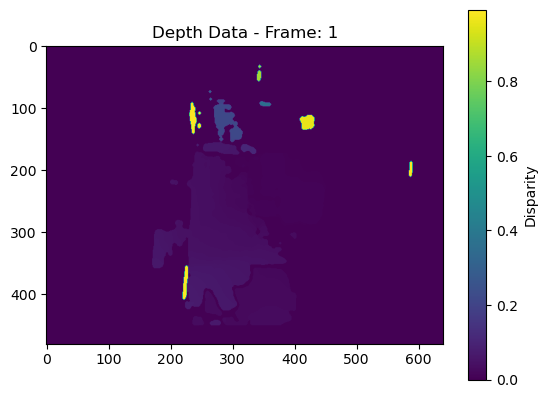

frame: 2
frame: 3
frame: 4
frame: 5
frame: 6
frame: 7
frame: 8
frame: 9
frame: 10
frame: 11
frame: 12
frame: 13
frame: 14
frame: 15
frame: 16
frame: 17
frame: 18
frame: 19
frame: 20
frame: 21
frame: 22
frame: 23
frame: 24
frame: 25
frame: 26
frame: 27
frame: 28
frame: 29
frame: 30
frame: 31
frame: 32
frame: 33
frame: 34
frame: 35
frame: 36
frame: 37
frame: 38
frame: 39
frame: 40
frame: 41
frame: 42
frame: 43
frame: 44
frame: 45
frame: 46
frame: 47
frame: 48
frame: 49
frame: 50
frame: 51
frame: 52
frame: 53
frame: 54
frame: 55
frame: 56
frame: 57
frame: 58
frame: 59
frame: 60
frame: 61
frame: 62
frame: 63
frame: 64
frame: 65
frame: 66
frame: 67
frame: 68
frame: 69
frame: 70
frame: 71
frame: 72
frame: 73
frame: 74
frame: 75
frame: 76
frame: 77
frame: 78
frame: 79
frame: 80
frame: 81
frame: 82
frame: 83
frame: 84
frame: 85
frame: 86
frame: 87
frame: 88
frame: 89
frame: 90
frame: 91
frame: 92
frame: 93
frame: 94
frame: 95
frame: 96
frame: 97
frame: 98
frame: 99
frame: 100
frame: 101
frame:

IndexError: list index out of range

In [61]:
import json
# image_dir = 'video/05_16_2025_10_33_14_trial_1/'
image_dir = 'video/05_16_2025_11_03_56_trial_2/'
left_folder = image_dir + "left"
right_folder = image_dir + "right"
extension = 'jpg'
left_files = glob.glob(os.path.join(left_folder, f"*.{extension}"))
right_files = glob.glob(os.path.join(right_folder, f"*.{extension}"))
left_files.sort(key=natural_sort_key)
right_files.sort(key=natural_sort_key)
num_frames = min(len(left_files), len(right_files))
print(f"Using {num_frames} frames from each folder")

left_files = left_files[:num_frames]
right_files = right_files[:num_frames]

def parse_cv_params():
    with open('cv_config.json') as config:
        param = json.load(config)
        _last_update = os.fstat(config.fileno()).st_mtime
    print(f"[MESSAGE] Config: {param}\n")    
    # Serializing json
    config_params = json.dumps(param, indent=14)
    return param, config_params
DIM=(640, 480)
cv_params, __ = parse_cv_params()
KL=np.array([[567.5108694496967, 0.0, 296.65113980779455], [0.0, 555.4066963178193, 209.8357339941157], [0.0, 0.0, 1.0]])
DL=np.array([[2.3304306359821676], [-22.72098020337239], [96.18495273925535], [-142.38468386964402]])
KR=np.array([[654.417602210813, 0.0, 236.58996237455327], [0.0, 625.1929731011552, 223.78494035869645], [0.0, 0.0, 1.0]])
DR=np.array([[-1.4455817082295017], [22.451030896752517], [-138.62442550617396], [291.546248181601]])
R=np.array([[0.9350531687261983, 0.001570069165988603, -0.3545040289445381], [-0.007541738734551825, 0.9998519807567543, -0.01546411179650275], [0.3544272758013351, 0.01713334350350178, 0.934926603915214]])
T=np.array([[-2.1428084390335562], [-0.02825237240566071], [-0.36330855915337945]])*25.4

KL=np.array([[708.3477312219868, 0.0, 260.69187590557686], [0.0, 675.3059166594338, 301.31936629865646], [0.0, 0.0, 1.0]])
DL=np.array([[-0.39383047117877457], [6.721465255404687], [-35.99917141986595], [61.49579122578909]])
KR=np.array([[667.0400978057647, 0.0, 334.8109094526051], [0.0, 644.922628956739, 364.07228200370565], [0.0, 0.0, 1.0]])
DR=np.array([[0.8809516193294453], [-6.609640306922403], [21.549513701823056], [-24.149385093847197]])
R=np.array([[0.8721459388442752, 0.02130940474841954, -0.4887815162490354], [-0.06589130347707366, 0.9950649291385254, -0.07418977641584823], [0.4847884048567273, 0.09691076342599622, 0.8692459412897253]])
T=np.array([[-2.085136618149882], [0.1939622251215522], [-0.9258137973647751]])*25.4


R1,R2,P1,P2,Q = cv2.fisheye.stereoRectify(KL,DL,KR,DR,DIM,R,T, cv2.fisheye.CALIB_ZERO_DISPARITY)
print(Q)
L_undist_map=cv2.fisheye.initUndistortRectifyMap(KL,DL,np.identity(3),KL,DIM,cv2.CV_32FC1)
R_undist_map=cv2.fisheye.initUndistortRectifyMap(KR,DR,np.identity(3),KR,DIM,cv2.CV_32FC1)
left1, left2 = cv2.fisheye.initUndistortRectifyMap(KL, DL, R1, P1, DIM, cv2.CV_32FC1)
right1, right2 = cv2.fisheye.initUndistortRectifyMap(KR,DR, R2, P2, DIM, cv2.CV_32FC1)
stereo = cv2.StereoBM.create(numDisparities=cv_params["numDisparities"], blockSize=cv_params["blockSize"])
stereo.setMinDisparity(cv_params["MinDisparity"])
stereo.setTextureThreshold(cv_params["TextureThreshold"])

#post filtering parameters: prevent false matches, help filter at boundaries
stereo.setSpeckleRange(cv_params["SpeckleRange"])
stereo.setSpeckleWindowSize(cv_params["SpeckleWindowSize"])
stereo.setUniquenessRatio(cv_params["UniquenessRatio"])

stereo.setDisp12MaxDiff(cv_params["Disp12MaxDiff"])

depth_mean_list = [10000000]
# depth_mean_list = [100]
first = 1
#  Try using widget backend for better interactivity
try:
    %matplotlib widget
except:
    %matplotlib inline
# count = 500
output_combined = []
disparities = []
for count in range(num_frames):
    print(f"frame: {count}")
    left = cv2.imread(left_files[count])
    right = cv2.imread(right_files[count])

    fixedLeft = cv2.remap(left, left1, left2, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    fixedRight = cv2.remap(right, right1, right2, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

    grayLeft = cv2.cvtColor(fixedLeft, cv2.COLOR_BGR2GRAY)
    grayRight = cv2.cvtColor(fixedRight, cv2.COLOR_BGR2GRAY)
    disparity = stereo.compute(grayLeft,grayRight)
    disparities.append(disparity)
    denoise = 5
    noise=cv2.erode(disparity,np.ones((denoise,denoise)))
    noise=cv2.dilate(noise,np.ones((denoise,denoise)))
    disparity = cv2.medianBlur(noise, ksize=5)
    # norm_disparity = cv2.normalize(disparity, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    invalid_pixels = disparity < 0.0001
    disparity[invalid_pixels] = 0
    norm_disparity = np.array((disparity/16.0 - stereo.getMinDisparity())/stereo.getNumDisparities(), dtype='f')
    norm_disparity = norm_disparity
    points3D = cv2.reprojectImageTo3D(np.array(disparity/16.0/1000.0, dtype='f'), Q, handleMissingValues=True)
    depth = Q[2,3]/Q[3,2]/np.array(disparity/16.0, dtype='f')/1000
    x_bounds = [158,613]
    y_bounds = [30,450]
    depth_window = depth[30:450,158:613]
    finite_depth = depth_window[np.isfinite(depth_window)]
    stop_mean = np.median(finite_depth)
    h_thresh = 80
    w_thresh = 100
    depth[np.isinf(depth)] = np.median(finite_depth)
    # print(np.mean(depth))


    depth_thresh = 1.5 # Threshold for SAFE distance (in cm)

    # Mask to segment regions with depth less than threshold
    mask = cv2.inRange(depth,0.1,depth_thresh)

    # Check if a significantly large obstacle is present and filter out smaller noisy regions
    if np.sum(mask)/255.0 > 0.01*mask.shape[0]*mask.shape[1]:
        
        # Contour detection 
        contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        cnts = sorted(contours, key=cv2.contourArea, reverse=True)
        
        # Check if detected contour is significantly large (to avoid multiple tiny regions)
        if cv2.contourArea(cnts[0]) > 0.03*mask.shape[0]*mask.shape[1]:
            # print("detected contour significantly large")
            x,y,w,h = cv2.boundingRect(cnts[0])
            x_center = int(x + w/2)
            y_center = int(y + h/2)
            # finding average depth of region represented by the largest contour 
            mask2 = np.zeros_like(mask)
            # cv2.imshow("depth", mask)
            # cv2.waitKey(1)
            # cv2.drawContours(mask2, cnts, 0, (255), -1)
            # cv2.drawContours(norm_disparity, cnts, 0, (255), -1)
            # Calculating the average depth of the object closer than the safe distance
            depth_mean, _ = cv2.meanStdDev(depth, mask=mask)
            
            # Display warning text
            # cv2.putText(norm_disparity, "WARNING !", (x+5,y-40), 1, 2, (0,0,255), 2, 2)
            # cv2.putText(norm_disparity, "Object at", (x+5,y), 1, 2, (100,10,25), 2, 2)
            # cv2.putText(norm_disparity, "%.2f m"%depth_mean, (x+5,y+40), 1, 2, (100,10,25), 2, 2)
            
            # STEER AWAY HERE
            # print(depth_thresh/depth_mean[0,0])
            # print(mask2)
            # - 1.0 + 2.0 * 1 / (1 + np.exp((depth_mean[0,0] - depth_thresh)/depth_thresh))
            depth_mean, _ = cv2.meanStdDev(depth, mask=mask2)
            # print(f"depth_mean: {depth_mean[0,0]}\n")
            if len(depth_mean_list) < 20:
                depth_mean_list.append(depth_mean[0,0])
            else:
                depth_mean_list.pop(0)
                depth_mean_list.append(depth_mean[0,0])
            # print(f"list: {depth_mean_list}")
            # print(depth_mean[0])
            filtered_depth = np.mean(depth_mean_list)
            output = filtered_depth, x, y, norm_disparity
            if filtered_depth < 2.5:
                x_bounds = [157,425]
                y_bounds = [30,450]
                if (x - 157) / (425 - 157) > 0.5:
                    print("turn right")
                    u_yaw = -1.0
                    u_roll = -1.0
                else:
                    print("turn left")
                    u_yaw = 1.0
                    u_roll = 1.0

            

            if first:
                plt.ion()
                fig, ax = plt.subplots()
                im = ax.imshow(norm_disparity)   
                vmin = np.min(norm_disparity)
                vmax = np.max(norm_disparity)
                
                # Initial plot
                im = ax.imshow(norm_disparity, cmap='viridis', vmin=vmin, vmax=vmax)
                title = ax.set_title(f'Depth Data - Frame: {count}')
                cbar = fig.colorbar(im, ax=ax, label='Disparity')

                plt.show()
                first = 0
            else:
                im.set_data(norm_disparity)
                fig.canvas.flush_events()
        else:
            # print("put text statment")
            cv2.putText(norm_disparity, "SAFE!", (100,100),1,3,(0,255,0),2,3)
            if len(depth_mean_list) < 20:
                depth_mean_list.append(np.mean(depth))
            else:
                depth_mean_list.pop(0)
                depth_mean_list.append(np.mean(depth))
            filtered_depth = np.mean(depth_mean_list)
            output = filtered_depth, None, None, norm_disparity
            if filtered_depth < 2.5:
                x_bounds = [157,425]
                y_bounds = [30,450]
                if (0 - 157) / (425 - 157) > 0.5:
                    print("turn right")
                    u_yaw = -1.0
                    u_roll = -1.0
                else:
                    print("turn left")
                    u_yaw = 1.0
                    u_roll = 1.0

            if first:
                plt.ion()
                fig, ax = plt.subplots()
                im = ax.imshow(norm_disparity)   
                vmin = np.min(norm_disparity)
                vmax = np.max(norm_disparity)
                
                # Initial plot
                im = ax.imshow(norm_disparity, cmap='viridis', vmin=vmin, vmax=vmax)
                title = ax.set_title(f'Depth Data - Frame: {count}')
                cbar = fig.colorbar(im, ax=ax, label='Disparity')

                plt.show()
                first = 0
            else:
                im.set_data(norm_disparity)
                fig.canvas.flush_events()
    else:
        # print("this else statement ")
        if len(depth_mean_list) < 20:
                depth_mean_list.append(np.mean(depth))
        else:
            depth_mean_list.pop(0)
            depth_mean_list.append(np.mean(depth))
        filtered_depth = np.mean(depth_mean_list)
        output = filtered_depth, None, None, norm_disparity
        if filtered_depth < 2.5:
            x_bounds = [157,425]
            y_bounds = [30,450]
            if (0 - 157) / (425 - 157) > 0.5:
                print("turn right")
                u_yaw = -1.0
                u_roll = -1.0
            else:
                print("turn left")
                u_yaw = 1.0
                u_roll = 1.0
        # if first:
        #     plt.ion()
        #     fig, ax = plt.subplots()
        #     im = ax.imshow(norm_disparity)   
        #     vmin = np.min(norm_disparity)
        #     vmax = np.max(norm_disparity)
            
        #     # Initial plot
        #     im = ax.imshow(norm_disparity, cmap='viridis', vmin=vmin, vmax=vmax)
        #     title = ax.set_title(f'Depth Data - Frame: {count}')
        #     cbar = fig.colorbar(im, ax=ax, label='Disparity')

        #     plt.show()
        #     first = 0
        # else:
        #     im.set_data(norm_disparity)
        #     fig.canvas.flush_events()
    stereo_depth_fname = 'video/05_16_2025_10_33_14_trial_1/depth_data'
    depth_files = load_depth_files(stereo_depth_fname)
    stored_norm_disparity = np.load(depth_files[count])
    # print(np.array_equal(norm_disparity, stored_norm_disparity))
    array1 = stored_norm_disparity
    array2 = norm_disparity
    diff = array1 - array2
    abs_diff = np.abs(diff)
    
    # Count exact matches
    exact_matches = np.sum(array1 == array2)
    total_elements = array1.size
    match_percent = 100 * exact_matches / total_elements
    # print(f"Matching elements: {exact_matches} out of {total_elements} ({match_percent:.2f}%)")

    # print(f"depth mean list: {depth_mean_list}")
    # print(f"output: {output[0]}")
    output_combined.append(output[0])
print(f"stereo depth: {stereo_depth_data[0:30]}")
other = np.unique(stereo_depth_data)
# print(f"num of unique vals: {other.shape}")

In [ ]:
print(len(output_combined))
print(len(disparities))

[12.47001076 12.32080555 11.73101139 11.29842854 11.05301189 10.98348141
 10.29423046 10.18575764 10.09220409  9.71520901  9.8927021   9.67596436
  9.62227058  9.40885735  9.33321667  9.52207088  9.88843727  9.42394447
  9.78602219  9.77150917  9.9981823  10.19605064  9.24700499  9.36823606
  9.29669104  9.62849283  9.92482879 10.24713857 11.19479883 11.07566364
 11.34613235 11.74869859 11.7128607  11.33965523 11.56585841 12.16641221
 11.54293659 11.23393407 11.09357724 10.84450734 10.58838447 10.32790569
 10.55439568 10.02017879  9.68141556  9.28923321  8.85800076  8.31903553
  7.23301697  7.17120457  6.79102087  6.39117765  6.15313244  6.39951229
  6.31937265  5.41644382  5.2091074   5.0607481   4.88259792  4.68831587
  4.63415003  4.4057951   4.34598875  4.26726055  4.34338188  4.33698559
  4.54657793  4.62027645  4.62772846  4.60629559  4.51138926  4.49227428
  4.50218296  4.33846378  4.23378468  4.37737274  4.81198549  5.24212551
  5.22542906  5.2403245   5.40171528  5.39913988  5

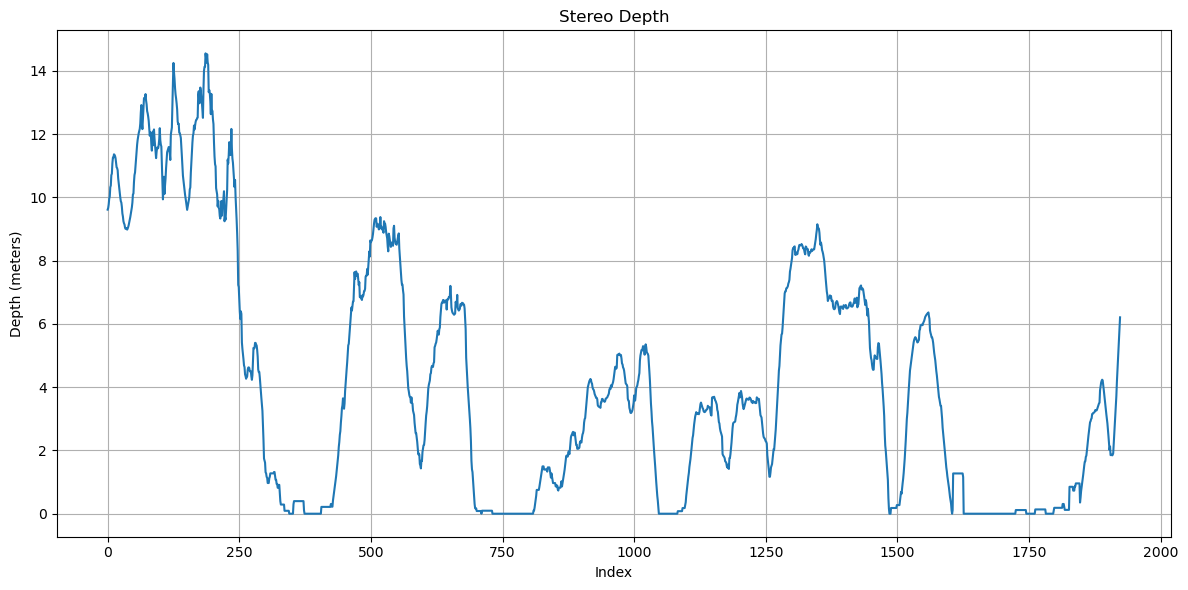

In [45]:
stereo_depth_data = np.array(output_combined[400:])
print(stereo_depth_data[200:300])
start_idx = 0
end_idx = stereo_depth_data.shape[0]
print(stereo_depth_data.shape)
# Create a figure and get the axes object
fig, ax = plt.subplots(figsize=(12, 6))
# Prepare x-axis data
if 't' in npz_file:
    t_data = npz_file['t']
    if len(t_data) == len(stereo_depth_data):
        x = t_data[start_idx:end_idx]
        x_label = 'Time (seconds)'
    else:
        x = np.arange(start_idx, end_idx)
        x_label = 'Index'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

if len(t_data) == len(stereo_depth_data):
    x = t_data[start_idx:end_idx]
    x_label = 'Time'
else:
    x = np.arange(start_idx, end_idx)
    x_label = 'Index'

# Plot using the axes object
ax.plot(x, stereo_depth_data[start_idx:end_idx])

# Add labels and title to the axes object
ax.set_xlabel(x_label)
ax.set_ylabel('Depth (meters)')
ax.set_title('Stereo Depth')
ax.grid(True)

plt.tight_layout()
plt.show()

### Obstacle avoidance for specific frame!
#### Trials 1 and 2

[DEBUG] Obstacle detected!
Contour 0: Area=8.0, Mean Intensity=1.4
Contour 1: Area=621.0, Mean Intensity=1.5
Contour 2: Area=22.0, Mean Intensity=1.4
Contour 3: Area=8171.5, Mean Intensity=1.3
Contour 4: Area=235.0, Mean Intensity=1.5
Contour 5: Area=387.5, Mean Intensity=0.3
Contour 6: Area=28.0, Mean Intensity=1.1
Contour 7: Area=48.5, Mean Intensity=0.3
Contour 8: Area=62.0, Mean Intensity=0.7
Contour 9: Area=124.5, Mean Intensity=0.3
Contour 10: Area=22.0, Mean Intensity=0.3
Contour 11: Area=12.0, Mean Intensity=0.3
Contour 12: Area=117.0, Mean Intensity=0.3
Contour 13: Area=12.0, Mean Intensity=0.9
Contour 14: Area=45.0, Mean Intensity=0.3
[DEBUG] Stereo depth: 2.7445630550384523


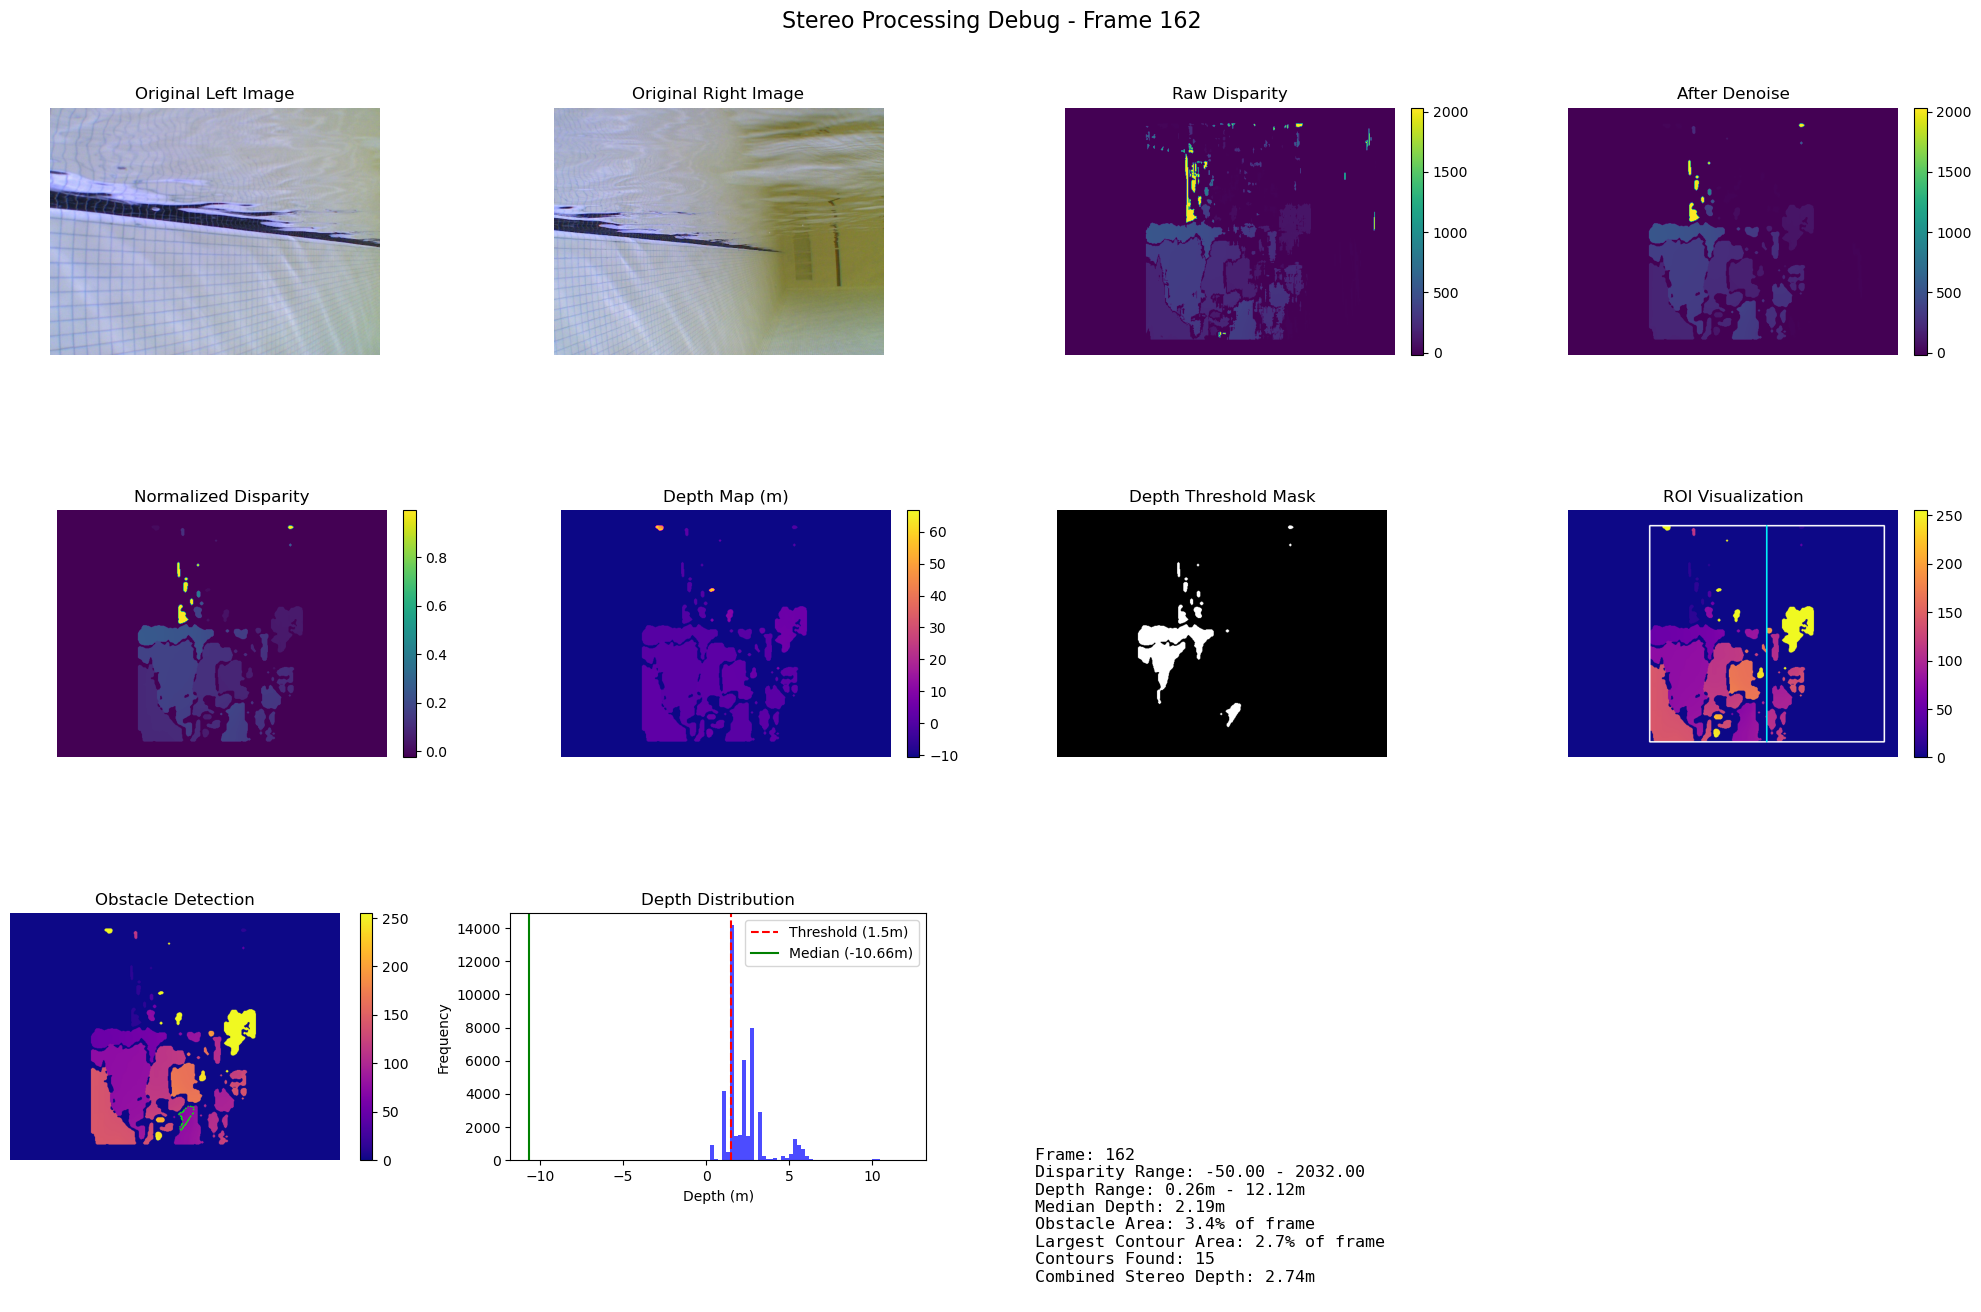

In [119]:
# TODO: check frame 165 and 499 and 507 


# TODO: also check out 680-690 frames


frame_idx = 162
# left = cv2.imread(left_files[count])
# right = cv2.imread(right_files[count])
# Create a figure with multiple subplots
plt.figure(figsize=(20, 16))
plt.suptitle(f"Stereo Processing Debug - Frame {frame_idx}", fontsize=16)
subplot_idx = 1

# Row 1: Original images and raw disparity
original_left = cv2.imread(left_files[frame_idx])
original_right = cv2.imread(right_files[frame_idx])

if original_left is not None and original_right is not None:
    plt.subplot(4, 4, subplot_idx)
    plt.imshow(original_left, cmap='gray' if len(original_left.shape) == 2 else None)
    plt.title("Original Left Image")
    plt.axis('off')
    subplot_idx += 1
    
    plt.subplot(4, 4, subplot_idx)
    plt.imshow(original_right, cmap='gray' if len(original_right.shape) == 2 else None)
    plt.title("Original Right Image")
    plt.axis('off')
    subplot_idx += 1

disparity = disparities[frame_idx].copy()
plt.subplot(4, 4, subplot_idx)
plt.imshow(disparity, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Raw Disparity")
plt.axis('off')
subplot_idx += 1

# all the denoising operations 
denoise = 5
noise=cv2.erode(disparity,np.ones((denoise,denoise)))
noise=cv2.dilate(noise,np.ones((denoise,denoise)))
disparity = cv2.medianBlur(noise, ksize=5)

# plot filtered disparity
plt.subplot(4, 4, subplot_idx)
plt.imshow(disparity, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("After Denoise")
plt.axis('off')
subplot_idx += 1

# handle invalid pixels
invalid_pixels = disparity < 0.0001
# disparity[invalid_pixels] = 0
disparity[invalid_pixels] = -50

# normalize disparity
norm_disparity = np.array((disparity/16.0 - stereo.getMinDisparity())/stereo.getNumDisparities(), dtype='f')
norm_disparity = norm_disparity

plt.subplot(4, 4, subplot_idx)
plt.imshow(norm_disparity, cmap='viridis')
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Normalized Disparity")
plt.axis('off')
subplot_idx += 1

# calculate depth map
points3D = cv2.reprojectImageTo3D(np.array(disparity/16.0/1000.0, dtype='f'), Q, handleMissingValues=True)
depth = Q[2,3]/Q[3,2]/np.array(disparity/16.0, dtype='f')/1000

# handle infinte depth cases
x_bounds = [158,613]
y_bounds = [30,450]
depth_window = depth[30:450,158:613]
finite_depth = depth_window[np.isfinite(depth_window)]
stop_mean = np.median(finite_depth)
h_thresh = 80
w_thresh = 100
depth[np.isinf(depth)] = np.median(finite_depth)

plt.subplot(4, 4, subplot_idx)
plt.imshow(depth, cmap='plasma')
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Depth Map (m)")
plt.axis('off')
subplot_idx += 1

# create mask for obstacle detection
depth_thresh = 1.5      # Threshold for SAFE distance (in cm)
# Mask to segment regions with depth less than threshold
mask = cv2.inRange(depth,0.1,depth_thresh)
plt.subplot(4, 4, subplot_idx)
plt.imshow(mask, cmap='gray')
plt.title("Depth Threshold Mask")
plt.axis('off')
subplot_idx += 1

# visualization if we see an obstacle
depth_vis = cv2.applyColorMap(
        cv2.convertScaleAbs(
            np.clip(depth, 0, 5) * 51, 
            alpha=1
        ), 
        cv2.COLORMAP_PLASMA
    )
# Draw ROI
roi_vis = depth_vis.copy()


cv2.rectangle(roi_vis, 
                (x_bounds[0], y_bounds[0]), 
                (x_bounds[1], y_bounds[1]), 
                (255, 255, 255), 2)
mid_x = (x_bounds[1] + x_bounds[0]) / 2
cv2.line(roi_vis, 
        (int(mid_x), y_bounds[0]), 
        (int(mid_x), y_bounds[1]), 
        (255, 255, 0), 2)
plt.subplot(4, 4, subplot_idx)
plt.imshow(cv2.cvtColor(roi_vis, cv2.COLOR_BGR2RGB), cmap='plasma')
plt.colorbar(fraction=0.046, pad=0.04)

plt.title("ROI Visualization")
plt.axis('off')
subplot_idx += 1
contour_vis = depth_vis.copy()
# Check if a significantly large obstacle is present and filter out smaller noisy regions
has_obstacle = np.sum(mask)/255.0 > 0.01*mask.shape[0]*mask.shape[1]
# if np.sum(mask)/255.0 > 0.01*mask.shape[0]*mask.shape[1]:
if has_obstacle:
    # Contour detection 
    print("[DEBUG] Obstacle detected!")
        # Create a visualization with the obstacles highlighted

    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # Get intensity for each contour
    for i, contour in enumerate(contours):
        # Create mask for this specific contour
        contour_mask = np.zeros(depth.shape[:2], dtype=np.uint8)
        cv2.fillPoly(contour_mask, [contour], 255)
        
        # Get mean intensity
        mean_intensity = cv2.mean(depth, mask=contour_mask)[0]
        area = cv2.contourArea(contour)
        
        print(f"Contour {i}: Area={area:.1f}, Mean Intensity={mean_intensity:.1f}")
    cnts = sorted(contours, key=cv2.contourArea, reverse=True)
    # area = cv2.contourArea(cnts[0])
    # print(f"Contour 0: {area} pixels")
    # area2 = cv2.contourArea(cnts[1])
    # print(f"Contour 1: {area2} pixels")


    # Draw all contours
    cv2.drawContours(contour_vis, cnts[1], -1, (0, 255, 0), 2)
    # Check if detected contour is significantly large (to avoid multiple tiny regions)
    if cv2.contourArea(cnts[0]) > 0.03*mask.shape[0]*mask.shape[1]:
        print("[DEBUG] Detected significantly large contour")
        x,y,w,h = cv2.boundingRect(cnts[0])
        print(f"(x,y): {x,y}")
        cv2.rectangle(contour_vis, (x, y), (x+w, y+h), (0, 0, 255), 3)

        # Draw center point
        x_center = int(x + w/2)
        y_center = int(y + h/2)
        print(f"x center: {x_center}")
        # cv2.circle(contour_vis, (x_center, y_center), 10, (255, 0, 0), -1)
        cv2.circle(contour_vis, (x_center, y_center), 10, (255, 0, 0), -1)

        # finding average depth of region represented by the largest contour 
        mask2 = np.zeros_like(mask)
        # Calculating the average depth of the object closer than the safe distance
        depth_mean, _ = cv2.meanStdDev(depth, mask=mask)
        
        # Display warning text
        depth_mean, _ = cv2.meanStdDev(depth, mask=mask2)
        
        x_planning_bounds = [157,425]        # trial 1 and trial 2 may 16th with depth < 2.5 with OG intrinsics from Zach
        y_planning_bounds = [30,450]

        cv2.rectangle(contour_vis, 
                (x_planning_bounds[0], y_planning_bounds[0]), 
                (x_planning_bounds[1], y_planning_bounds[1]), 
                (255, 255, 255), 2)

        # Highlight decision boundaries for turning
        if x_planning_bounds[0] <= x_center <= x_planning_bounds[1]:
            mid_x = (x_planning_bounds[1] + x_planning_bounds[0]) / 2
            print(f"mid x: {mid_x}")
            cv2.line(contour_vis, 
                    (int(mid_x), y_bounds[0]), 
                    (int(mid_x), y_bounds[1]), 
                    (255, 255, 0), 2)
            
            print(f"x location: {x}")
            check = (x_center - 157) / (425 - 157)
            print(f"check: {check}")
            # Indicate turn direction
            if check > 0.5:
                TURN_RIGHT = False
            else:
                TURN_RIGHT = True

            turn_text = "TURN RIGHT" if TURN_RIGHT else "TURN LEFT"
            cv2.putText(contour_vis, turn_text, 
                        (int(mid_x) - 280, y_bounds[0]),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
    else:
        # print("put text statment")
        # cv2.putText(norm_disparity, "SAFE!", (100,100),1,3,(0,255,0),2,3)
        x = 0.0
        y = 0.0
else:
    x = 0.0
    y = 0.0


plt.subplot(4, 4, subplot_idx)
plt.imshow(cv2.cvtColor(contour_vis, cv2.COLOR_BGR2RGB), cmap='plasma')
plt.title("Obstacle Detection" if has_obstacle else "No Obstacles Detected")
plt.colorbar()
plt.axis('off')
subplot_idx += 1
stereo_depth = output_combined[frame_idx]
print(f"[DEBUG] Stereo depth: {stereo_depth}")

# Histograms and statistical visualizations
valid_depth = depth[np.isfinite(depth) & (depth > 0) & (depth < 20)]

if len(valid_depth) > 0:
    plt.subplot(4, 4, subplot_idx)
    plt.hist(valid_depth.flatten(), bins=50, color='blue', alpha=0.7)
    plt.axvline(x=depth_thresh, color='r', linestyle='--', 
                label=f'Threshold ({depth_thresh}m)')
    if len(finite_depth) > 0:
        plt.axvline(x=np.median(finite_depth), color='g', linestyle='-', 
                    label=f'Median ({np.median(finite_depth):.2f}m)')
    plt.title("Depth Distribution")
    plt.xlabel("Depth (m)")
    plt.ylabel("Frequency")
    plt.legend()
    subplot_idx += 1

# Add statistics as text
stats_text = f"Frame: {frame_idx}\n"
stats_text += f"Disparity Range: {np.min(disparity):.2f} - {np.max(disparity):.2f}\n"

if len(valid_depth) > 0:
    stats_text += f"Depth Range: {np.min(valid_depth):.2f}m - {np.max(valid_depth):.2f}m\n"
    stats_text += f"Median Depth: {np.median(valid_depth):.2f}m\n"

if has_obstacle:
    stats_text += f"Obstacle Area: {np.sum(mask)/255.0/(mask.shape[0]*mask.shape[1]):.1%} of frame\n"
    
    if len(cnts) > 0:
        stats_text += f"Largest Contour Area: {cv2.contourArea(cnts[0])/(mask.shape[0]*mask.shape[1]):.1%} of frame\n"
        stats_text += f"Contours Found: {len(contours)}\n"
        
        if cv2.contourArea(cnts[0]) > 0.03*mask.shape[0]*mask.shape[1]:
            x, y, w, h = cv2.boundingRect(cnts[0])
            x_center = int(x + w/2)
            y_center = int(y + h/2)
            stats_text += f"Obstacle Center: ({x_center}, {y_center})\n"
            stats_text += f"Obstacle Size: {w}×{h} pixels\n"
            
            # Create mask for the largest contour
            mask2 = np.zeros_like(mask)
            cv2.drawContours(mask2, [cnts[0]], 0, 255, -1)
            
            # Calculate mean depth in the contour
            depth_mean, depth_std = cv2.meanStdDev(depth, mask=mask2)
            stats_text += f"Obstacle Depth: {depth_mean[0][0]:.2f}m ± {depth_std[0][0]:.2f}m\n"

if output_combined is not None:
    stereo_depth = output_combined[frame_idx]
    stats_text += f"Combined Stereo Depth: {stereo_depth:.2f}m\n"

plt.subplot(4, 4, subplot_idx)
plt.text(0.05, 0.05, stats_text, fontsize=12, family='monospace', 
        verticalalignment='top')
plt.axis('off')
subplot_idx += 1

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust for the suptitle
plt.savefig(f"stereo_debug_frame_{frame_idx}.png", dpi=150)
plt.show()
if stereo_depth < 2.5:
    x_bounds = [157,425]
    y_bounds = [30,450]
    if (x - 157) / (425 - 157) > 0.5:
        u_yaw = -1.0
        u_roll = -1.0
    else:
        u_yaw = 1.0
        u_roll = 1.0

plt.show()


### Make a video that shows obstacle avoidance!
#### Trials 1 and 2

In [104]:
def obstacle_avoidance_video(left_folder, right_folder, depth_folder, output_path, 
                         fps=30, extension="jpg", depth_extension="npy", start_frame=0):
    """
    Create a composite video showing left, right, and depth images with frame counter
    
    Args:
        left_folder (str): Path to folder containing left camera images
        right_folder (str): Path to folder containing right camera images
        depth_folder (str): Path to folder containing depth data files
        output_path (str): Path where to save the output video
        fps (int): Frames per second for the output video
        extension (str): File extension for left/right images
        depth_extension (str): File extension for depth files
        start_frame (int): Starting frame number for the counter
    
    Returns:
        bool: True if successful, False otherwise
    """
    # Check if folders exist
    if not all(os.path.exists(folder) for folder in [left_folder, right_folder, depth_folder]):
        print("Error: One or more directories not found.")
        return False
    
    # Find all files
    left_files = glob.glob(os.path.join(left_folder, f"*.{extension}"))
    right_files = glob.glob(os.path.join(right_folder, f"*.{extension}"))
    depth_files = glob.glob(os.path.join(depth_folder, f"*.{depth_extension}"))
    
    if not all([left_files, right_files, depth_files]):
        print("Error: No files found in one or more folders.")
        return False
    
    # Sort files naturally
    left_files.sort(key=natural_sort_key)
    right_files.sort(key=natural_sort_key)
    depth_files.sort(key=natural_sort_key)
    
    # Ensure all folders have the same number of files
    num_frames = min(len(left_files), len(right_files), len(depth_files))
    print(f"Using {num_frames} frames from each folder")
    
    left_files = left_files[:num_frames]
    right_files = right_files[:num_frames]
    depth_files = depth_files[:num_frames]
    
    # Stereo Processor images
    def parse_cv_params():
        with open('cv_config.json') as config:
            param = json.load(config)
            _last_update = os.fstat(config.fileno()).st_mtime
        print(f"[MESSAGE] Config: {param}\n")    
        # Serializing json
        config_params = json.dumps(param, indent=14)
        return param, config_params
    
    DIM=(640, 480)
    cv_params, __ = parse_cv_params()
    KL=np.array([[567.5108694496967, 0.0, 296.65113980779455], [0.0, 555.4066963178193, 209.8357339941157], [0.0, 0.0, 1.0]])
    DL=np.array([[2.3304306359821676], [-22.72098020337239], [96.18495273925535], [-142.38468386964402]])
    KR=np.array([[654.417602210813, 0.0, 236.58996237455327], [0.0, 625.1929731011552, 223.78494035869645], [0.0, 0.0, 1.0]])
    DR=np.array([[-1.4455817082295017], [22.451030896752517], [-138.62442550617396], [291.546248181601]])
    R=np.array([[0.9350531687261983, 0.001570069165988603, -0.3545040289445381], [-0.007541738734551825, 0.9998519807567543, -0.01546411179650275], [0.3544272758013351, 0.01713334350350178, 0.934926603915214]])
    T=np.array([[-2.1428084390335562], [-0.02825237240566071], [-0.36330855915337945]])*25.4

    KL=np.array([[708.3477312219868, 0.0, 260.69187590557686], [0.0, 675.3059166594338, 301.31936629865646], [0.0, 0.0, 1.0]])
    DL=np.array([[-0.39383047117877457], [6.721465255404687], [-35.99917141986595], [61.49579122578909]])
    KR=np.array([[667.0400978057647, 0.0, 334.8109094526051], [0.0, 644.922628956739, 364.07228200370565], [0.0, 0.0, 1.0]])
    DR=np.array([[0.8809516193294453], [-6.609640306922403], [21.549513701823056], [-24.149385093847197]])
    R=np.array([[0.8721459388442752, 0.02130940474841954, -0.4887815162490354], [-0.06589130347707366, 0.9950649291385254, -0.07418977641584823], [0.4847884048567273, 0.09691076342599622, 0.8692459412897253]])
    T=np.array([[-2.085136618149882], [0.1939622251215522], [-0.9258137973647751]])*25.4


    R1,R2,P1,P2,Q = cv2.fisheye.stereoRectify(KL,DL,KR,DR,DIM,R,T, cv2.fisheye.CALIB_ZERO_DISPARITY)
    print(Q)
    L_undist_map=cv2.fisheye.initUndistortRectifyMap(KL,DL,np.identity(3),KL,DIM,cv2.CV_32FC1)
    R_undist_map=cv2.fisheye.initUndistortRectifyMap(KR,DR,np.identity(3),KR,DIM,cv2.CV_32FC1)
    left1, left2 = cv2.fisheye.initUndistortRectifyMap(KL, DL, R1, P1, DIM, cv2.CV_32FC1)
    right1, right2 = cv2.fisheye.initUndistortRectifyMap(KR,DR, R2, P2, DIM, cv2.CV_32FC1)
    stereo = cv2.StereoBM.create(numDisparities=cv_params["numDisparities"], blockSize=cv_params["blockSize"])
    stereo.setMinDisparity(cv_params["MinDisparity"])
    stereo.setTextureThreshold(cv_params["TextureThreshold"])

    #post filtering parameters: prevent false matches, help filter at boundaries
    stereo.setSpeckleRange(cv_params["SpeckleRange"])
    stereo.setSpeckleWindowSize(cv_params["SpeckleWindowSize"])
    stereo.setUniquenessRatio(cv_params["UniquenessRatio"])

    stereo.setDisp12MaxDiff(cv_params["Disp12MaxDiff"])

    # when I change the depth_mean_ list to 100 then I start seeing what I originally was seeing
    depth_mean_list = [10000000]

    # Read first images to get dimensions
    first_left = cv2.imread(left_files[0])
    first_right = cv2.imread(right_files[0])
    
    if first_left is None or first_right is None:
        print("Error: Could not read one or both of the first images")
        return False
    
    # Load first depth file to get dimensions
    try:
        first_depth = np.load(depth_files[0])
        # Normalize depth for visualization (convert to grayscale image)
        depth_min = np.min(first_depth[~np.isnan(first_depth) & ~np.isinf(first_depth)])
        depth_max = np.max(first_depth[~np.isnan(first_depth) & ~np.isinf(first_depth)])
        first_depth = np.nan_to_num(first_depth, nan=depth_min, posinf=depth_max, neginf=depth_min)
        normalized_depth = ((first_depth - depth_min) / (depth_max - depth_min) * 255).astype(np.uint8)
        # Convert to color image for visualization
        first_depth_color = cv2.applyColorMap(normalized_depth, cv2.COLORMAP_VIRIDIS)
    except Exception as e:
        print(f"Error loading first depth file: {e}")
        return False
    
    # Get dimensions
    h_left, w_left, _ = first_left.shape
    h_right, w_right, _ = first_right.shape
    h_depth, w_depth = first_depth.shape[:2]
    
    # Resize all images to the same height
    target_height = min(h_left, h_right, h_depth)
    
    # Calculate new widths maintaining aspect ratio
    w_left_new = int(w_left * target_height / h_left)
    w_right_new = int(w_right * target_height / h_right)
    w_depth_new = int(w_depth * target_height / h_depth)
    
    # Compute composite dimensions
    # We'll place images in a row: [Left | Right | Depth | Obstacle]
    composite_width = w_left_new + w_right_new + w_depth_new + w_depth_new
    composite_height = target_height + 30  # Extra space for frame counter at the bottom
    
    # Create video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(output_path, fourcc, fps, (composite_width, composite_height))
    
    
    # Process each set of images
    print(f"Creating obstacle avoidance video: {output_path}")
    for i in tqdm(range(num_frames)):
        # Read left and right images
        left_img = cv2.imread(left_files[i])
        right_img = cv2.imread(right_files[i])
        left = left_img.copy()
        right = right_img.copy()
        fixedLeft = cv2.remap(left, left1, left2, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
        fixedRight = cv2.remap(right, right1, right2, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
        grayLeft = cv2.cvtColor(fixedLeft, cv2.COLOR_BGR2GRAY)
        grayRight = cv2.cvtColor(fixedRight, cv2.COLOR_BGR2GRAY)
        disparity = stereo.compute(grayLeft,grayRight)
        denoise = 5
        noise=cv2.erode(disparity,np.ones((denoise,denoise)))
        noise=cv2.dilate(noise,np.ones((denoise,denoise)))
        disparity = cv2.medianBlur(noise, ksize=5)
        invalid_pixels = disparity < 0.0001
        disparity[invalid_pixels] = -50
        norm_disparity = np.array((disparity/16.0 - stereo.getMinDisparity())/stereo.getNumDisparities(), dtype='f')
        norm_disparity = norm_disparity
        points3D = cv2.reprojectImageTo3D(np.array(disparity/16.0/1000.0, dtype='f'), Q, handleMissingValues=True)
        depth = Q[2,3]/Q[3,2]/np.array(disparity/16.0, dtype='f')/1000
        x_bounds = [158,613]
        y_bounds = [30,450]
        depth_window = depth[30:450,158:613]
        finite_depth = depth_window[np.isfinite(depth_window)]
        stop_mean = np.median(finite_depth)
        h_thresh = 80
        w_thresh = 100
        depth[np.isinf(depth)] = np.median(finite_depth)
        depth_thresh = 1.5 # Threshold for SAFE distance (in cm)
        contour_vis = cv2.applyColorMap(
            cv2.convertScaleAbs(
                np.clip(depth, 0, 5) * 51, 
                alpha=1
            ), 
            cv2.COLORMAP_PLASMA
        )

        # Mask to segment regions with depth less than threshold
        mask = cv2.inRange(depth,0.1,depth_thresh)
        if np.sum(mask)/255.0 > 0.01*mask.shape[0]*mask.shape[1]:
            
            # Contour detection 
            contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            cnts = sorted(contours, key=cv2.contourArea, reverse=True)
            # Draw all contours
            cv2.drawContours(contour_vis, contours, -1, (0, 255, 0), 2)

            # Check if detected contour is significantly large (to avoid multiple tiny regions)
            if cv2.contourArea(cnts[0]) > 0.03*mask.shape[0]*mask.shape[1]:
                x,y,w,h = cv2.boundingRect(cnts[0])
                x_center = int(x + w/2)
                y_center = int(y + h/2)
                # draw rectangle surrounding largest array
                cv2.rectangle(contour_vis, (x, y), (x+w, y+h), (0, 0, 255), 3)
                # draw center of largest area
                cv2.circle(contour_vis, (x_center, y_center), 10, (255, 0, 0), -1)
                # finding average depth of region represented by the largest contour 
                mask2 = np.zeros_like(mask)
                depth_mean, _ = cv2.meanStdDev(depth, mask=mask)
                depth_mean, _ = cv2.meanStdDev(depth, mask=mask2)
                if len(depth_mean_list) < 20:
                    depth_mean_list.append(depth_mean[0,0])
                else:
                    depth_mean_list.pop(0)
                    depth_mean_list.append(depth_mean[0,0])
                filtered_depth = np.mean(depth_mean_list)
                if filtered_depth < 2.5:
                    x_planning_bounds = [157,425]       
                    # Highlight decision boundaries for turning
                    if x_planning_bounds[0] <= x_center <= x_planning_bounds[1]:
                        mid_x = (x_planning_bounds[0] + x_planning_bounds[1]) / 2
                        cv2.line(contour_vis, 
                                (int(mid_x), y_bounds[0]), 
                                (int(mid_x), y_bounds[1]), 
                                (255, 255, 0), 2)
                        
                        # Indicate turn direction
                        if (x_center - 157) / (425 - 157) > 0.5:
                            TURN_RIGHT = False
                        else:
                            TURN_RIGHT = True

                        turn_text = "TURN RIGHT" if TURN_RIGHT else "TURN LEFT"
                        cv2.putText(contour_vis, turn_text, 
                                    (int(mid_x) - 280, y_bounds[0]),
                                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

            else:
                if len(depth_mean_list) < 20:
                    depth_mean_list.append(np.mean(depth))
                else:
                    depth_mean_list.pop(0)
                    depth_mean_list.append(np.mean(depth))
                filtered_depth = np.mean(depth_mean_list)
                x = 0
                y = 0
        else:
            if len(depth_mean_list) < 20:
                    depth_mean_list.append(np.mean(depth))
            else:
                depth_mean_list.pop(0)
                depth_mean_list.append(np.mean(depth))
            filtered_depth = np.mean(depth_mean_list)
            x = 0
            y = 0

        # Load and process depth
        try:
            depth_data = np.load(depth_files[i])
            # Handle NaN or inf values
            depth_data = np.nan_to_num(depth_data, nan=depth_min, posinf=depth_max, neginf=depth_min)
            # Normalize to 0-255 for visualization
            normalized_depth = ((depth_data - depth_min) / (depth_max - depth_min) * 255).astype(np.uint8)
            # Apply colormap for better visualization
            depth_color = cv2.applyColorMap(normalized_depth, cv2.COLORMAP_VIRIDIS)
        except Exception as e:
            print(f"Error processing depth file {i}: {e}")
            # Create a blank image if there's an error
            depth_color = np.zeros((h_depth, w_depth, 3), dtype=np.uint8)
        
        # Resize images to target height
        left_resized = cv2.resize(left_img, (w_left_new, target_height))
        right_resized = cv2.resize(right_img, (w_right_new, target_height))
        depth_resized = cv2.resize(depth_color, (w_depth_new, target_height))
        obstacle_resized = cv2.resize(contour_vis, (w_depth_new, target_height))

        # Create composite frame with black background
        composite = np.zeros((composite_height, composite_width, 3), dtype=np.uint8)
        
        # Place images side by side
        composite[:target_height, :w_left_new] = left_resized
        composite[:target_height, w_left_new:w_left_new+w_right_new] = right_resized
        composite[:target_height, w_left_new+w_right_new:w_left_new+w_right_new+w_depth_new] = depth_resized
        composite[:target_height, w_left_new+w_right_new+w_depth_new:] = obstacle_resized

        # Add labels
        cv2.putText(composite, "Left", (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(composite, "Right", (w_left_new + 10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(composite, "Depth", (w_left_new + w_right_new + 10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(composite, "Obstacle Detection", (w_left_new + w_right_new + w_depth_new + 10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Add frame counter
        frame_text = f"Frame: {i + start_frame}"
        text_size = cv2.getTextSize(frame_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
        text_x = (composite_width - text_size[0]) // 2
        cv2.putText(composite, frame_text, (text_x, composite_height - 10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Add to video
        video_writer.write(composite)
    
    # Release video writer
    video_writer.release()
    print(f"video saved to {output_path}")
    
    return True

In [105]:
# stereo_fname = 'video/05_16_2025_10_33_14_trial_1/'
stereo_fname = 'video/05_16_2025_11_03_56_trial_2/'
left_path = stereo_fname + 'left'
right_path = stereo_fname + 'right'
depth_path = stereo_fname + 'depth_data'
output_path = stereo_fname + "obstacle_avoidance_video.mp4"
fps = 20

obstacle_avoidance_video(
    left_path, 
    right_path, 
    depth_path, 
    output_path,
    fps
)

Using 3907 frames from each folder
[MESSAGE] Config: {'phi': 0.0, 'minThreshold': 10, 'maxThreshold': 200, 'minArea': 50, 'maxArea': 100000, 'minCircularity': 0.1, 'minConvexity': 0.1, 'minInertiaRatio': 0.1, 'lower_yellow': [10, 35, 50], 'upper_yellow': [30, 70, 100], 'turn_thresh': 150, 'dive_thresh': 100, 'num_cycles': 1, 'numDisparities': 128, 'blockSize': 61, 'MinDisparity': 0, 'TextureThreshold': 0, 'SpeckleRange': 2, 'SpeckleWindowSize': 5, 'UniquenessRatio': 2, 'Disp12MaxDiff': 2}

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -1.67895172e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -3.30655578e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.72967548e+02]
 [ 0.00000000e+00  0.00000000e+00  1.71947199e-02 -0.00000000e+00]]
Creating obstacle avoidance video: video/05_16_2025_11_03_56_trial_2/obstacle_avoidance_video.mp4


100%|██████████| 3907/3907 [04:29<00:00, 14.51it/s]

video saved to video/05_16_2025_11_03_56_trial_2/obstacle_avoidance_video.mp4


True

### Obstacle Avoidance Trials 3 and 4